# EMPLOYEE ATTRITION ANALYSIS

#GOAL OR AIM OF THIS CAPSTONE PROJECT

OUR GOAL IS TO FIND THE KEY CONTRIBUTORS FOR EMPLOYEE ATTRITION USING THIS DATA AND HELP HR TEAM TO UNDERSTAND THE TRENDS TO AVOID OR TAKE NECESSARY ACTION USING THE INSIGHTS PROVIDED BY THIS ANALYSIS.


#STEP 1 : TO IMPORT ALL THE NECESSARY LIBRARY TO PERFORM THIS ANALYSIS

In [4]:
# ---- Data Manipulation ----
import pandas as pd
import numpy as np

# ---- Visualization ----
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ---- Preprocessing ----
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# ---- Machine Learning Models ----
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# ---- Model Evaluation ----
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

# ---- Class Imbalance Handling ----
from imblearn.over_sampling import SMOTE

# ---- Miscellaneous ----
import warnings
warnings.filterwarnings('ignore')

# ---- Plot Styling ----
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Colour palette for consistent visuals
ATTRITION_COLORS = {'No': '#2196F3', 'Yes': '#F44336'}

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


#STEP 2 : LOAD AND UNDERSTAND THE DATA

In [5]:
#Load the dataset
df = pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition (1).csv')

print(f"📐 Dataset Shape : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"🗂️  Total Features : {df.shape[1] - 1} (excluding target)")
df.head()

📐 Dataset Shape : 1470 rows × 35 columns
🗂️  Total Features : 34 (excluding target)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
# Column data types & non-null counts
# This tells us which columns are numeric vs. categorical
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel  

In [7]:
# ── Statistical summary of numeric columns ────────────────────
# Mean, std, min/max — helps us spot outliers and understand scale
print("📈 Descriptive Statistics (Numeric Columns):")
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

📈 Descriptive Statistics (Numeric Columns):


,count,mean,std,min,25%,50%,75%,max
Age,1470.000000,36.923810,9.135373,18.000000,30.000000,36.000000,43.000000,60.000000
DailyRate,1470.000000,802.485714,403.509100,102.000000,465.000000,802.000000,1157.000000,1499.000000
DistanceFromHome,1470.000000,9.192517,8.106864,1.000000,2.000000,7.000000,14.000000,29.000000
Education,1470.000000,2.912925,1.024165,1.000000,2.000000,3.000000,4.000000,5.000000
EmployeeCount,1470.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
EmployeeNumber,1470.000000,1024.865306,602.024335,1.000000,491.250000,1020.500000,1555.750000,2068.000000
EnvironmentSatisfaction,1470.000000,2.721769,1.093082,1.000000,2.000000,3.000000,4.000000,4.000000
HourlyRate,1470.000000,65.891156,20.329428,30.000000,48.000000,66.000000,83.750000,100.000000
JobInvolvement,1470.000000,2.729932,0.711561,1.000000,2.000000,3.000000,3.000000,4.000000
JobLevel,1470.000000,2.063946,1.106940,1.000000,1.000000,2.000000,3.000000,5.000000


 Target Variable — Attrition:
  No  (Stayed)  : 1233  (83.9%)
  Yes (Left)    :  237  (16.1%)

 Class Imbalance Ratio ≈ 1 : 5
    We will handle this with SMOTE later.


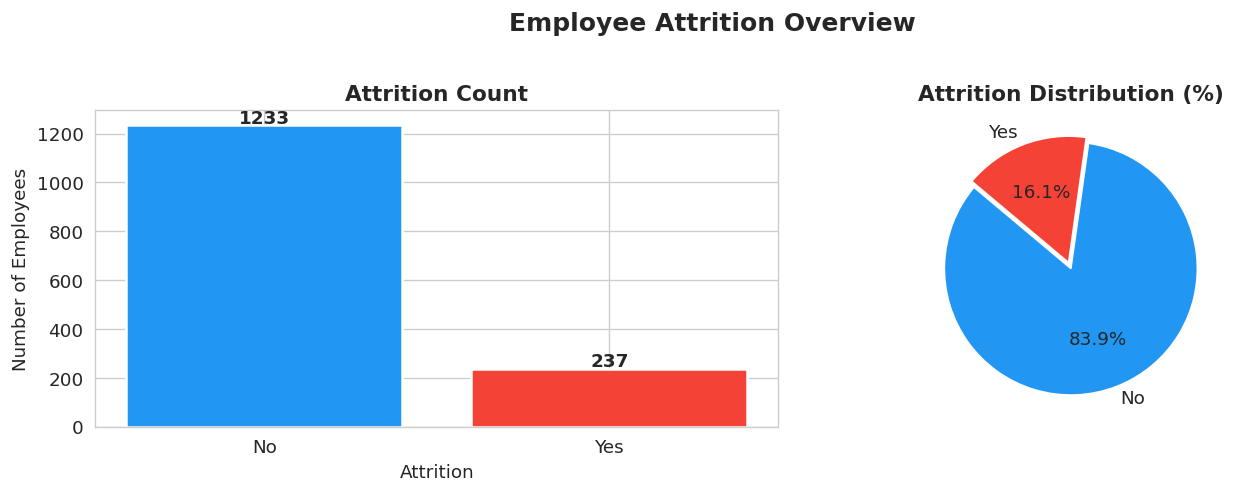

In [8]:
# Target variable distribution
# Our goal is to predict 'Attrition' (Yes/No)
attrition_counts = df['Attrition'].value_counts()
attrition_pct    = df['Attrition'].value_counts(normalize=True) * 100

print(" Target Variable — Attrition:")
print(f"  No  (Stayed)  : {attrition_counts['No']:>4}  ({attrition_pct['No']:.1f}%)")
print(f"  Yes (Left)    : {attrition_counts['Yes']:>4}  ({attrition_pct['Yes']:.1f}%)")
print(f"\n Class Imbalance Ratio ≈ 1 : {attrition_counts['No']//attrition_counts['Yes']}")
print("    We will handle this with SMOTE later.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(attrition_counts.index, attrition_counts.values,
            color=[ATTRITION_COLORS[k] for k in attrition_counts.index],
            edgecolor='white', linewidth=1.5)
axes[0].set_title('Attrition Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Number of Employees')
for i, v in enumerate(attrition_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(attrition_counts.values,
            labels=attrition_counts.index,
            autopct='%1.1f%%',
            colors=[ATTRITION_COLORS[k] for k in attrition_counts.index],
            startangle=140, explode=[0, 0.05])
axes[1].set_title('Attrition Distribution (%)', fontsize=13, fontweight='bold')

plt.suptitle('Employee Attrition Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Step 3: Data Cleaning
- Check for missing values
- Remove useless columns (zero-variance columns)
- Check for duplicates
- Validate data ranges

In [9]:
# 3.1  Missing Values
missing = df.isnull().sum()
print("🔍 Missing Values per Column:")
if missing.sum() == 0:
    print("   ✅ No missing values found! Dataset is complete.")
else:
    print(missing[missing > 0])

🔍 Missing Values per Column:
   ✅ No missing values found! Dataset is complete.


In [10]:
# 3.2  Duplicate Rows
dupes = df.duplicated().sum()
print(f"🔍 Duplicate Rows: {dupes}")
if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f"   ✅ Removed {dupes} duplicates.")
else:
    print("   ✅ No duplicate rows found!")

🔍 Duplicate Rows: 0
   ✅ No duplicate rows found!


In [11]:
# 3.3  Remove Zero-Variance (Constant) Columns
# Columns where every row has the same value add NO information to a model
const_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"🗑️  Constant Columns to Drop: {const_cols}")

df.drop(columns=const_cols, inplace=True)
print(f"   ✅ Dropped {len(const_cols)} column(s): {const_cols}")
print(f"   New shape: {df.shape}")

🗑️  Constant Columns to Drop: ['EmployeeCount', 'Over18', 'StandardHours']
   ✅ Dropped 3 column(s): ['EmployeeCount', 'Over18', 'StandardHours']
   New shape: (1470, 32)


In [12]:
# 3.4  Drop ID Column
# 'EmployeeNumber' is just an ID — it has no predictive value
df.drop(columns=['EmployeeNumber'], inplace=True, errors='ignore')
print("✅ Dropped 'EmployeeNumber' (ID column — not useful for modelling)")
print(f"   Final cleaned shape: {df.shape}")

✅ Dropped 'EmployeeNumber' (ID column — not useful for modelling)
   Final cleaned shape: (1470, 31)


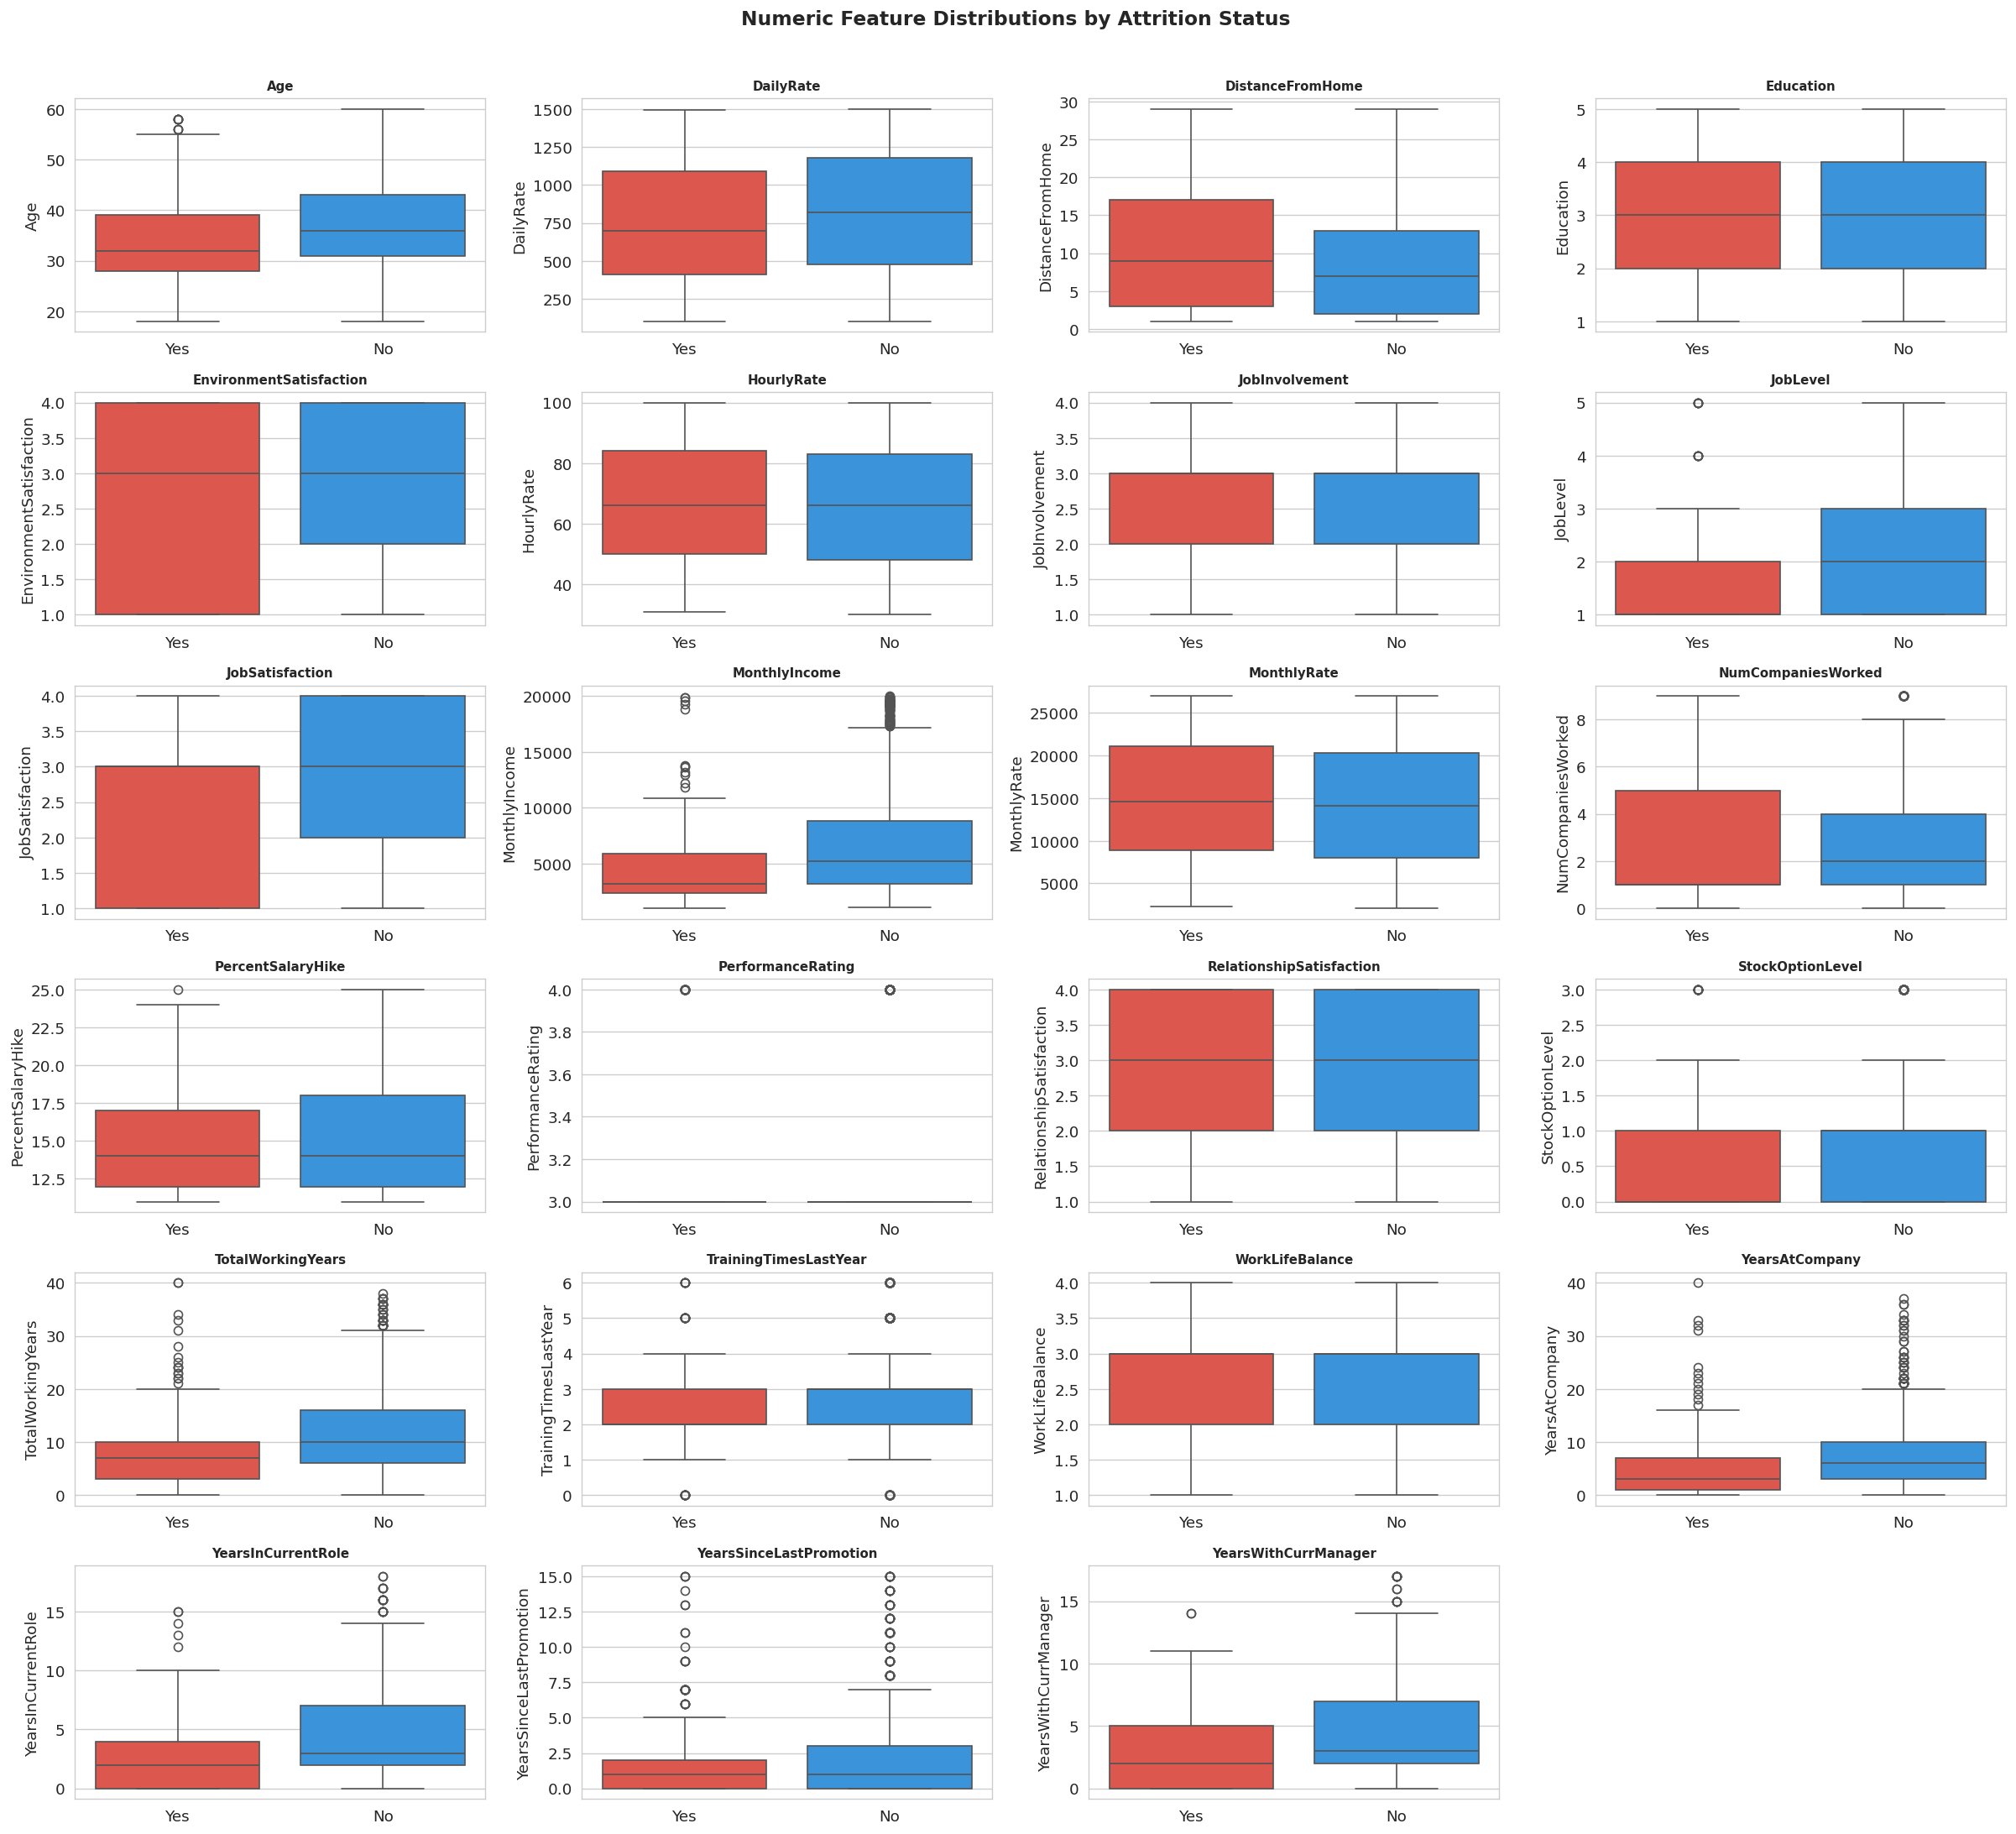


💡 Tip: Features where the two boxes are clearly separated are strong predictors!


In [13]:
# 3.5  Outlier Visualisation (Box Plots)
# We visualise but do NOT remove outliers — in HR data, extreme values
# (like very high salaries) are real and informative.

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='Attrition', y=col,
                palette=ATTRITION_COLORS, ax=axes[i])
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions by Attrition Status',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print("\n💡 Tip: Features where the two boxes are clearly separated are strong predictors!")

# Step 4: Exploratory Data Analysis (EDA)

EDA is where we *listen to the data*. We look for patterns, trends, and relationships that help us understand WHY employees leave.

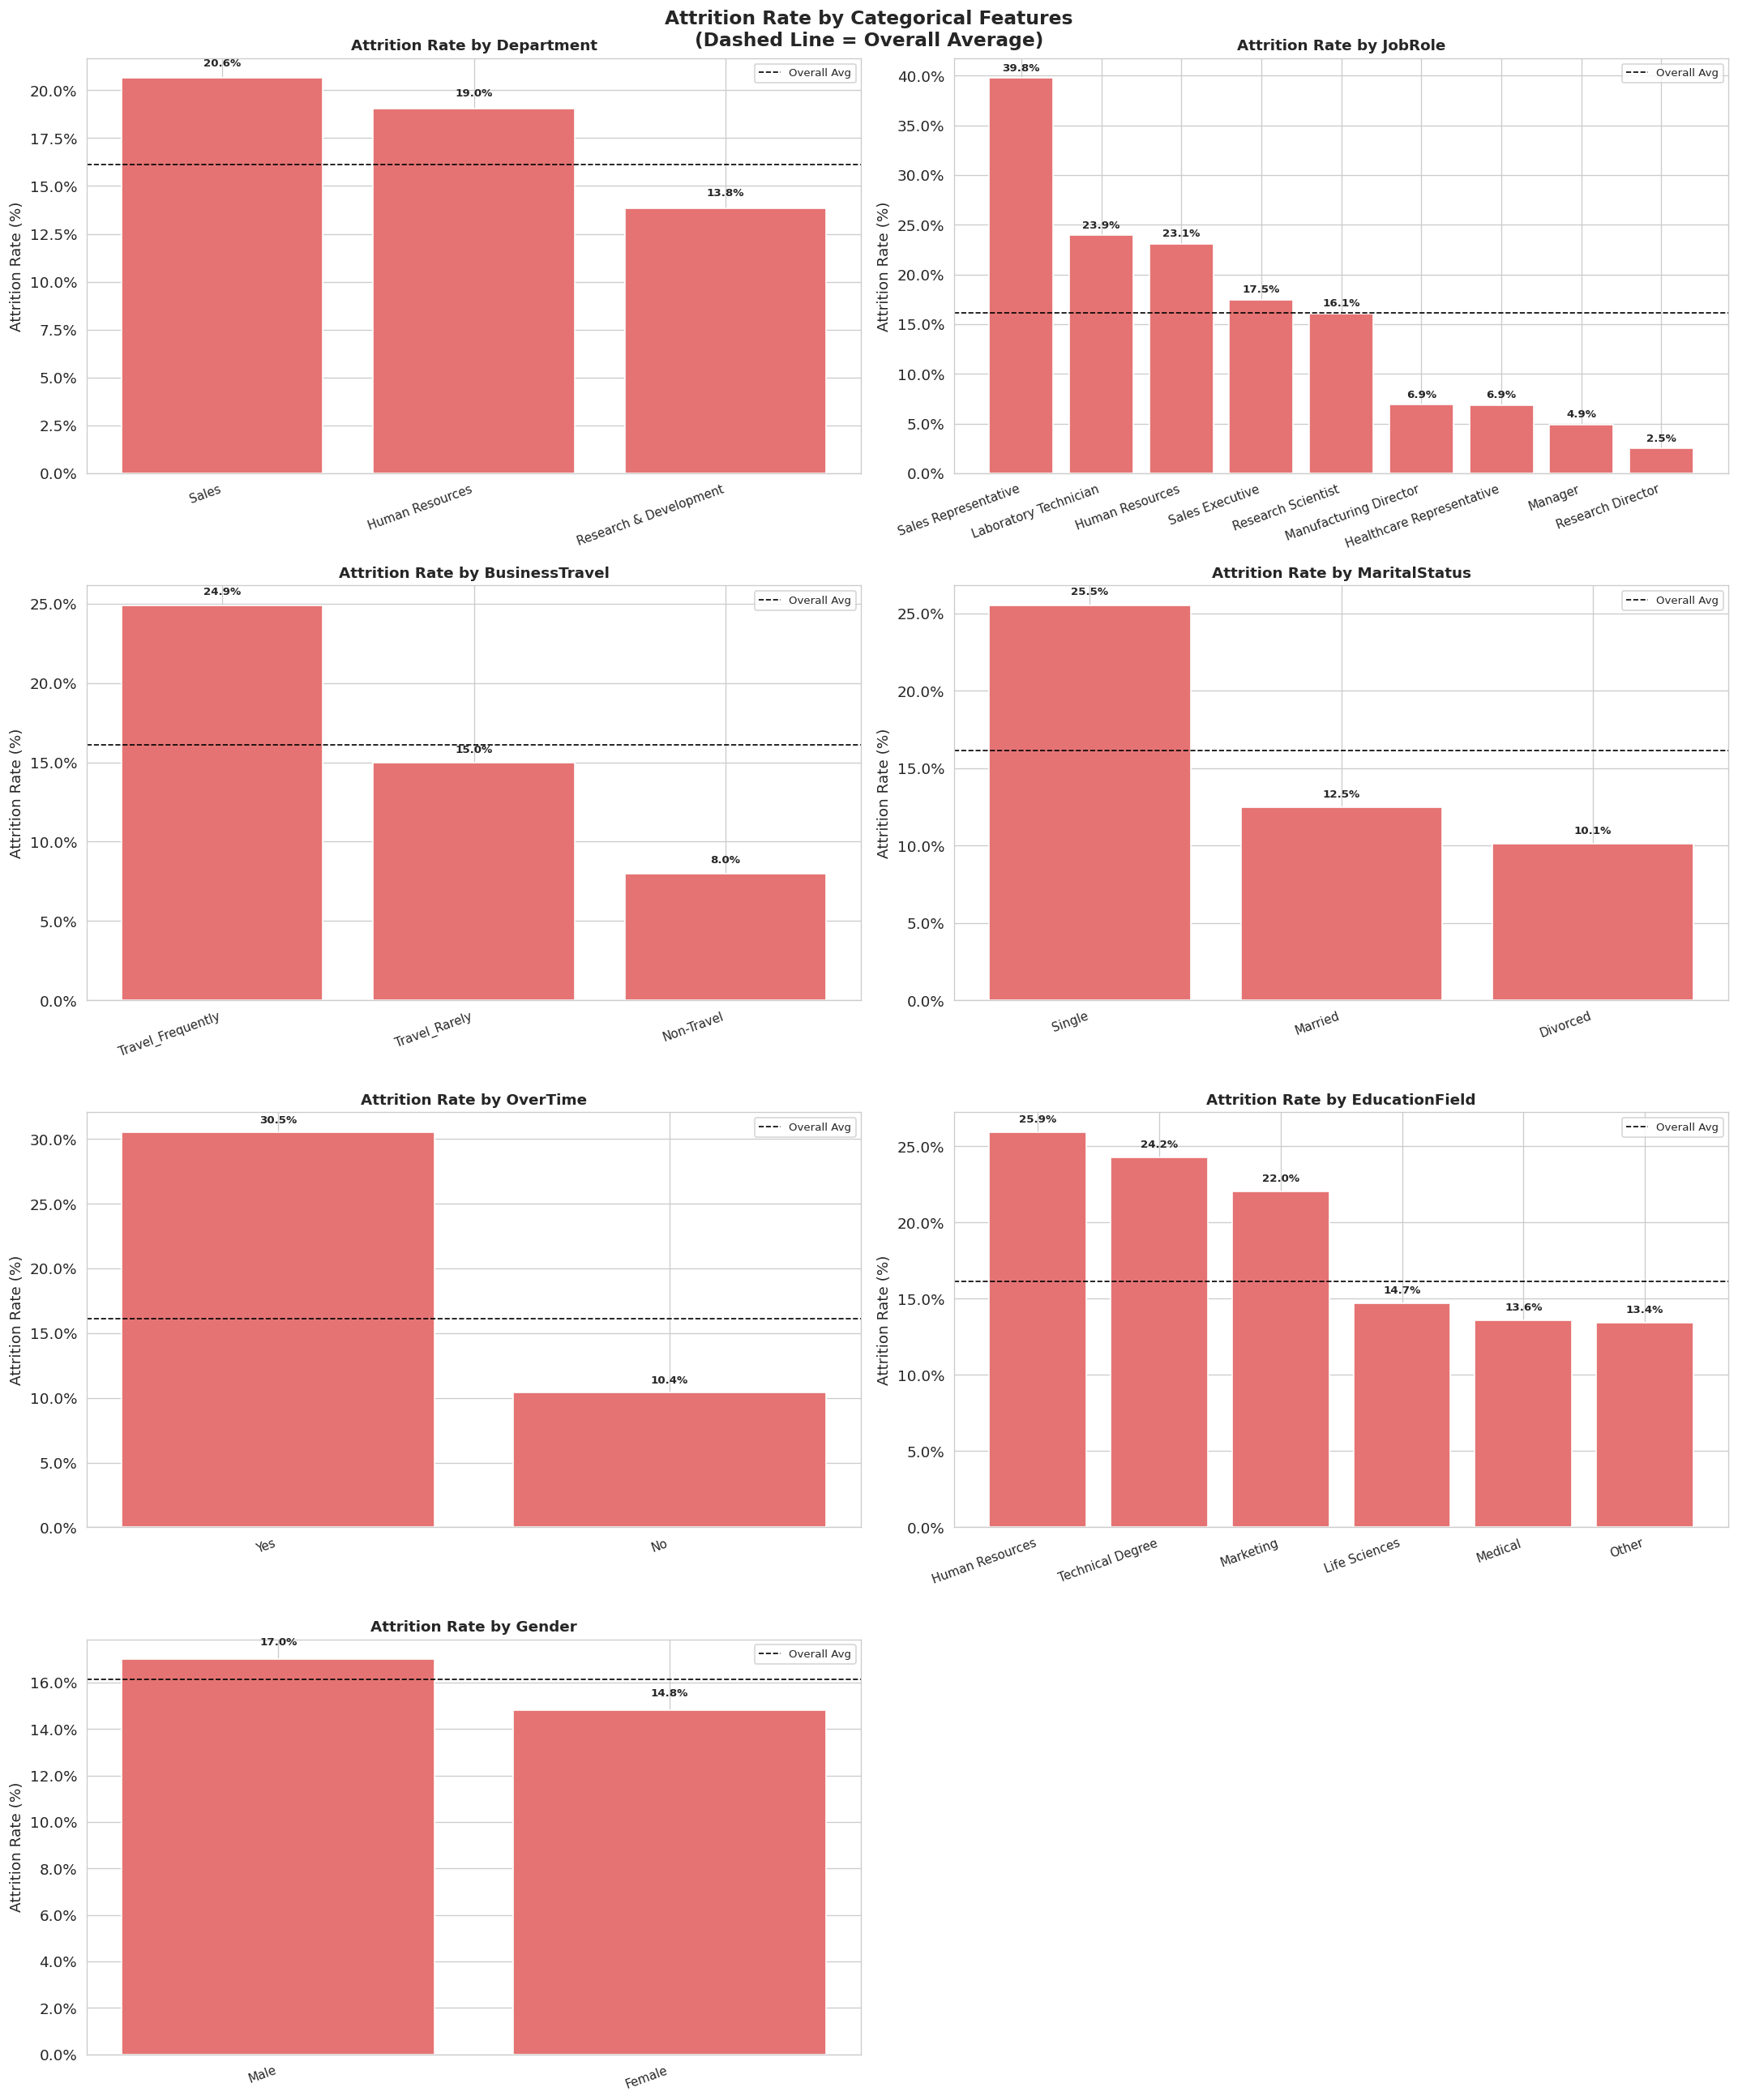

In [14]:
# ── 4.1  Attrition Rate by Key Categorical Features ──────────
cat_features = ['Department', 'JobRole', 'BusinessTravel',
                'MaritalStatus', 'OverTime', 'EducationField', 'Gender']

fig, axes = plt.subplots(4, 2, figsize=(18, 22))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    # Calculate attrition rate (%) per category
    temp = (df.groupby(feat)['Attrition']
              .apply(lambda x: (x == 'Yes').mean() * 100)
              .reset_index()
              .rename(columns={'Attrition': 'Attrition Rate (%)'}))
    temp = temp.sort_values('Attrition Rate (%)', ascending=False)

    bars = axes[i].bar(temp[feat], temp['Attrition Rate (%)'],
                       color='#E57373', edgecolor='white')
    axes[i].set_title(f'Attrition Rate by {feat}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Attrition Rate (%)')
    axes[i].set_xticklabels(temp[feat], rotation=20, ha='right', fontsize=9)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[i].axhline(y=df['Attrition'].eq('Yes').mean() * 100,
                    color='black', linestyle='--', linewidth=1, label='Overall Avg')
    axes[i].legend(fontsize=8)

    for bar, val in zip(bars, temp['Attrition Rate (%)']):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.5, f'{val:.1f}%',
                     ha='center', va='bottom', fontsize=8, fontweight='bold')

axes[-1].set_visible(False)
plt.suptitle('Attrition Rate by Categorical Features\n(Dashed Line = Overall Average)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

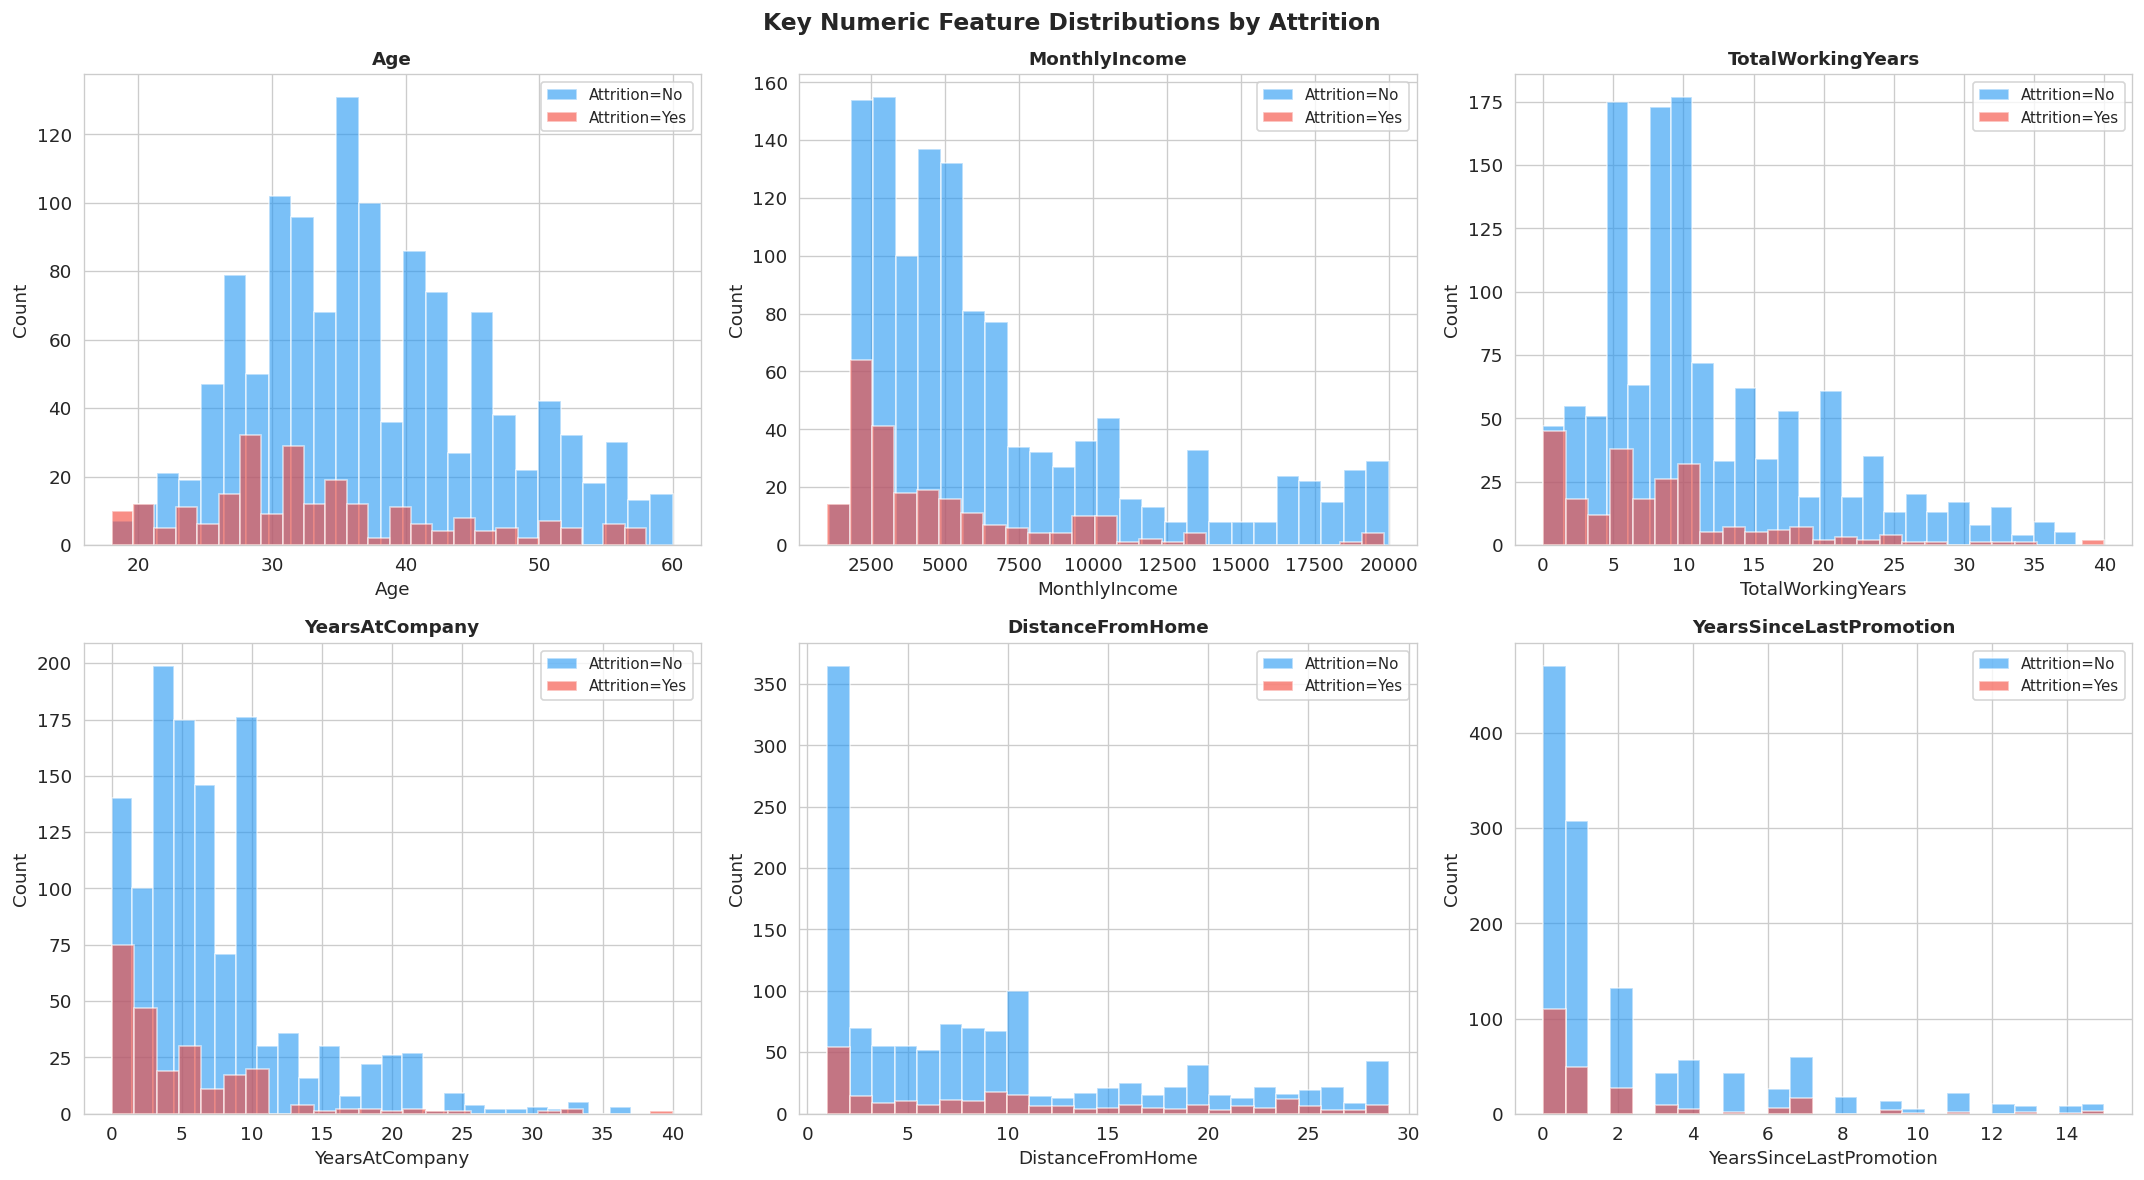

In [17]:
# 4.2  Age, Income & Experience Distribution by Attrition
focus_cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears',
              'YearsAtCompany', 'DistanceFromHome', 'YearsSinceLastPromotion']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(focus_cols):
    for label, color in ATTRITION_COLORS.items():
        subset = df[df['Attrition'] == label][col]
        axes[i].hist(subset, bins=25, alpha=0.6, color=color,
                     label=f'Attrition={label}', edgecolor='white')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=9)

plt.suptitle('Key Numeric Feature Distributions by Attrition',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

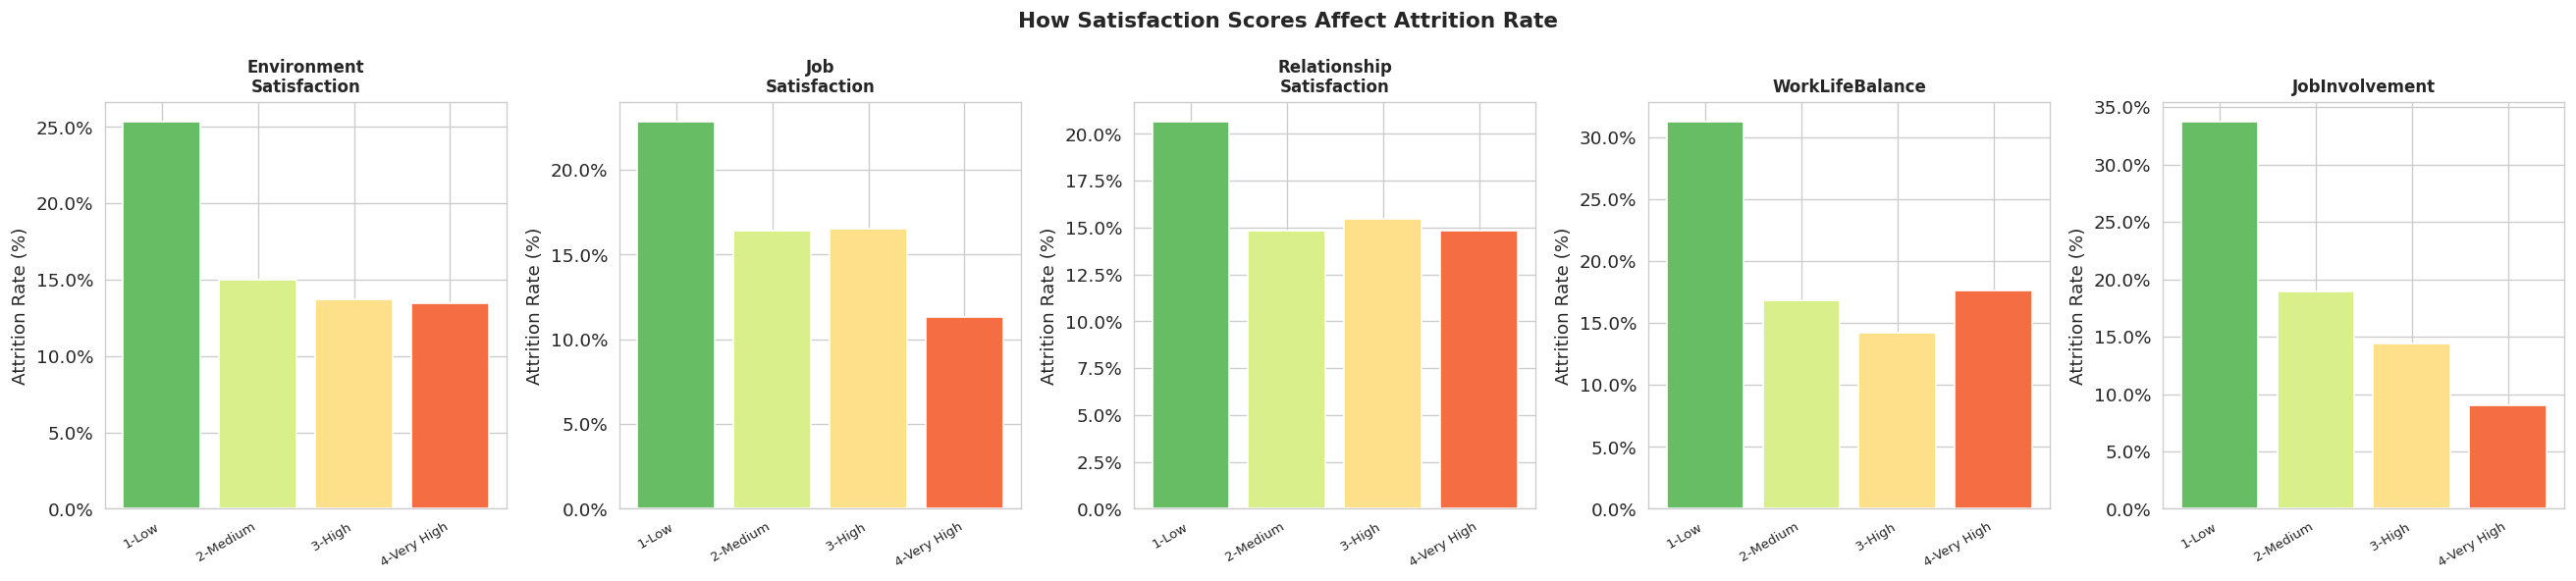

💡 Lower satisfaction → Higher attrition rate (as expected!)


In [18]:
# 4.3  Satisfaction Scores & Attrition
# These are rated 1–4. Let's see how satisfaction links to leaving.
satisfaction_cols = [
    'EnvironmentSatisfaction', 'JobSatisfaction',
    'RelationshipSatisfaction', 'WorkLifeBalance', 'JobInvolvement'
]

labels_map = {1: '1-Low', 2: '2-Medium', 3: '3-High', 4: '4-Very High'}

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for i, col in enumerate(satisfaction_cols):
    temp = (df.groupby(col)['Attrition']
              .apply(lambda x: (x == 'Yes').mean() * 100)
              .reset_index()
              .rename(columns={'Attrition': 'Rate'}))
    temp[col] = temp[col].map(labels_map)

    axes[i].bar(temp[col], temp['Rate'],
                color=sns.color_palette('RdYlGn_r', len(temp)),
                edgecolor='white')
    axes[i].set_title(col.replace('Satisfaction', '\nSatisfaction'),
                      fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Attrition Rate (%)')
    axes[i].set_xticklabels(temp[col], rotation=30, ha='right', fontsize=8)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('How Satisfaction Scores Affect Attrition Rate',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("💡 Lower satisfaction → Higher attrition rate (as expected!)")

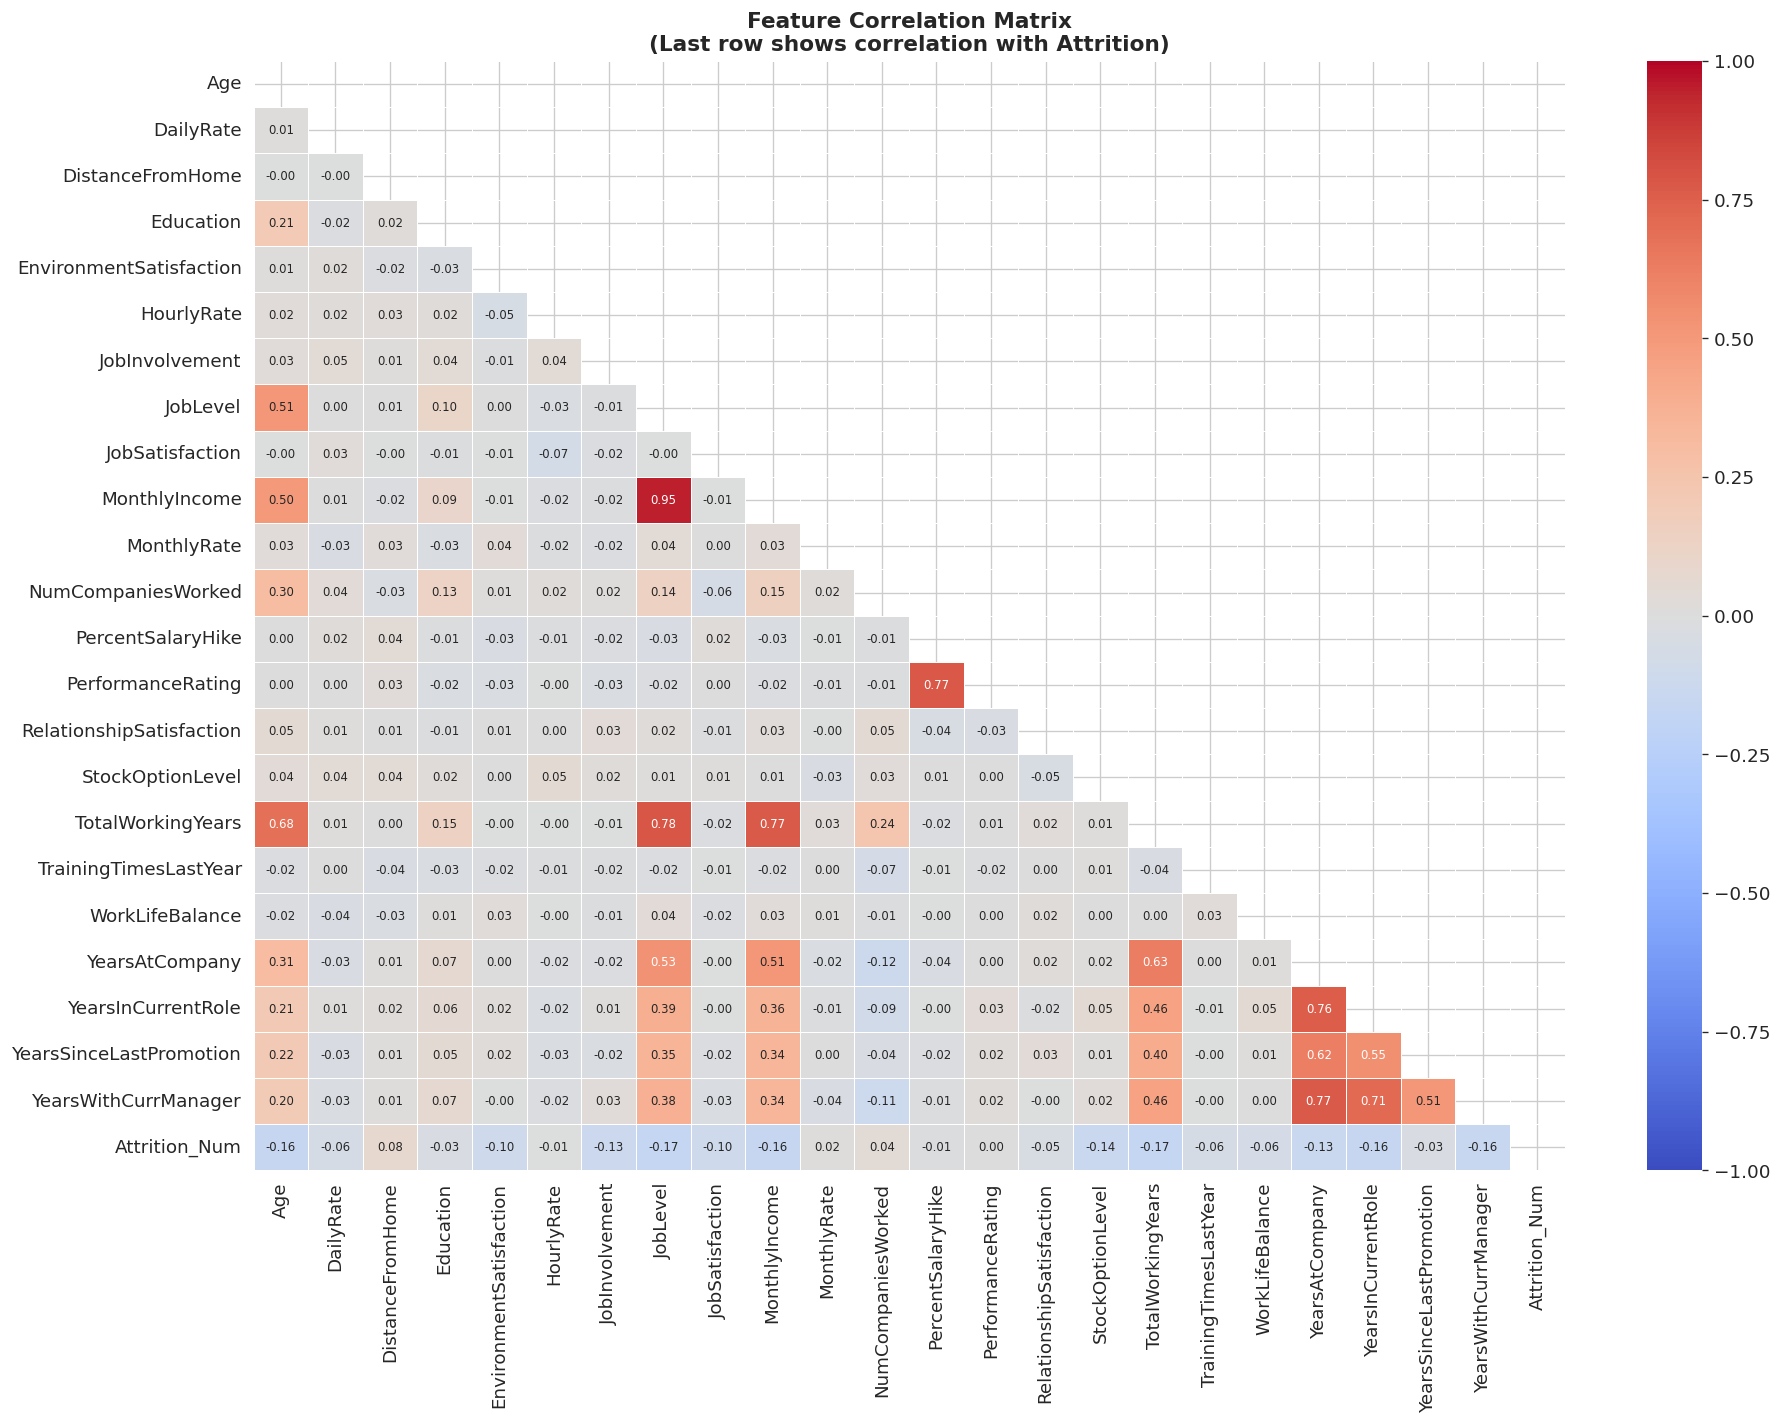


📊 Top 10 Features Correlated with Attrition:
TotalWorkingYears       0.171063
JobLevel                0.169105
YearsInCurrentRole      0.160545
MonthlyIncome           0.159840
Age                     0.159205
YearsWithCurrManager    0.156199
StockOptionLevel        0.137145
YearsAtCompany          0.134392
JobInvolvement          0.130016
JobSatisfaction         0.103481


In [19]:
# 4.4  Correlation Heatmap
# Create a temporary numeric version for correlation
df_corr = df.copy()
df_corr['Attrition_Num'] = (df_corr['Attrition'] == 'Yes').astype(int)

corr_matrix = df_corr[numeric_cols + ['Attrition_Num']].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, annot_kws={'size': 7},
            vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix\n(Last row shows correlation with Attrition)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top correlated features with Attrition
attrition_corr = (corr_matrix['Attrition_Num']
                   .drop('Attrition_Num')
                   .abs()
                   .sort_values(ascending=False)
                   .head(10))
print("\n📊 Top 10 Features Correlated with Attrition:")
print(attrition_corr.to_string())

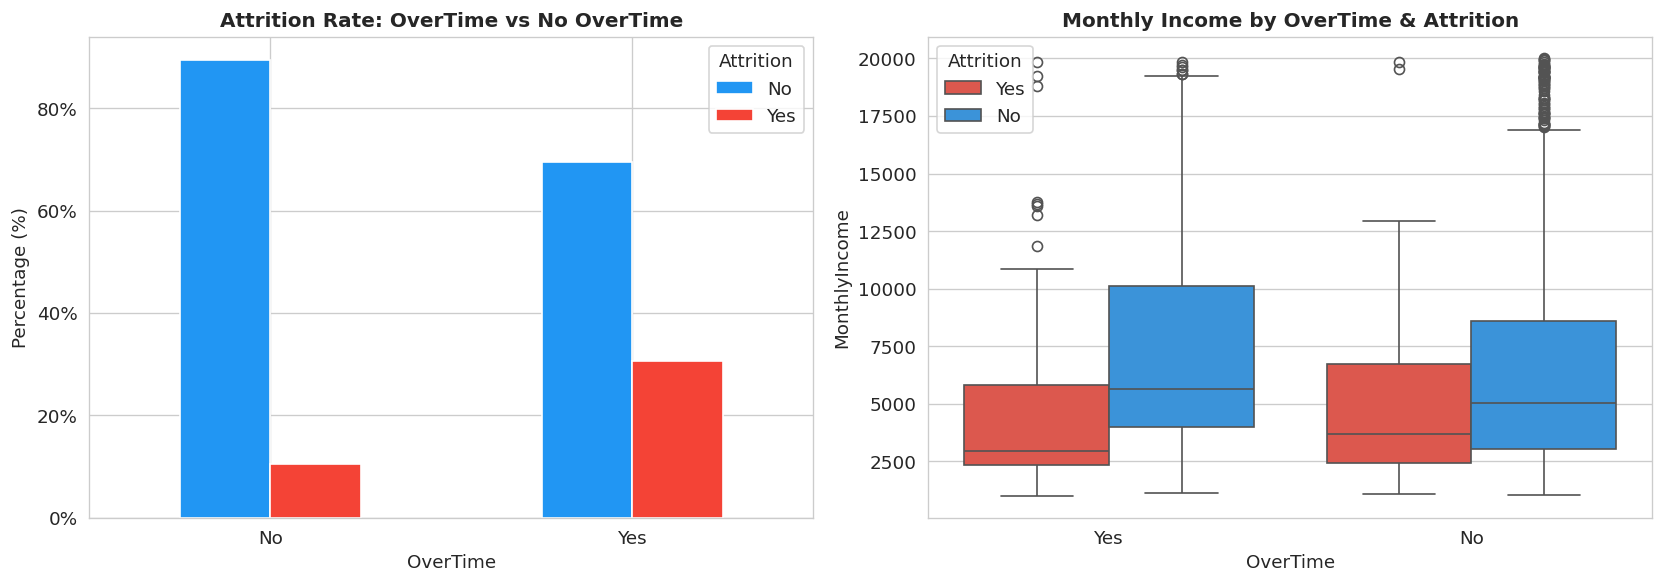

In [20]:
# 4.5  OverTime vs Attrition (One of the BIGGEST factors)
overtime_pivot = pd.crosstab(df['OverTime'], df['Attrition'],
                             normalize='index') * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

overtime_pivot.plot(kind='bar', ax=axes[0],
                    color=list(ATTRITION_COLORS.values()),
                    edgecolor='white', rot=0)
axes[0].set_title('Attrition Rate: OverTime vs No OverTime',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].legend(title='Attrition')

# Income vs OverTime boxplot
sns.boxplot(data=df, x='OverTime', y='MonthlyIncome',
            hue='Attrition', palette=ATTRITION_COLORS, ax=axes[1])
axes[1].set_title('Monthly Income by OverTime & Attrition',
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

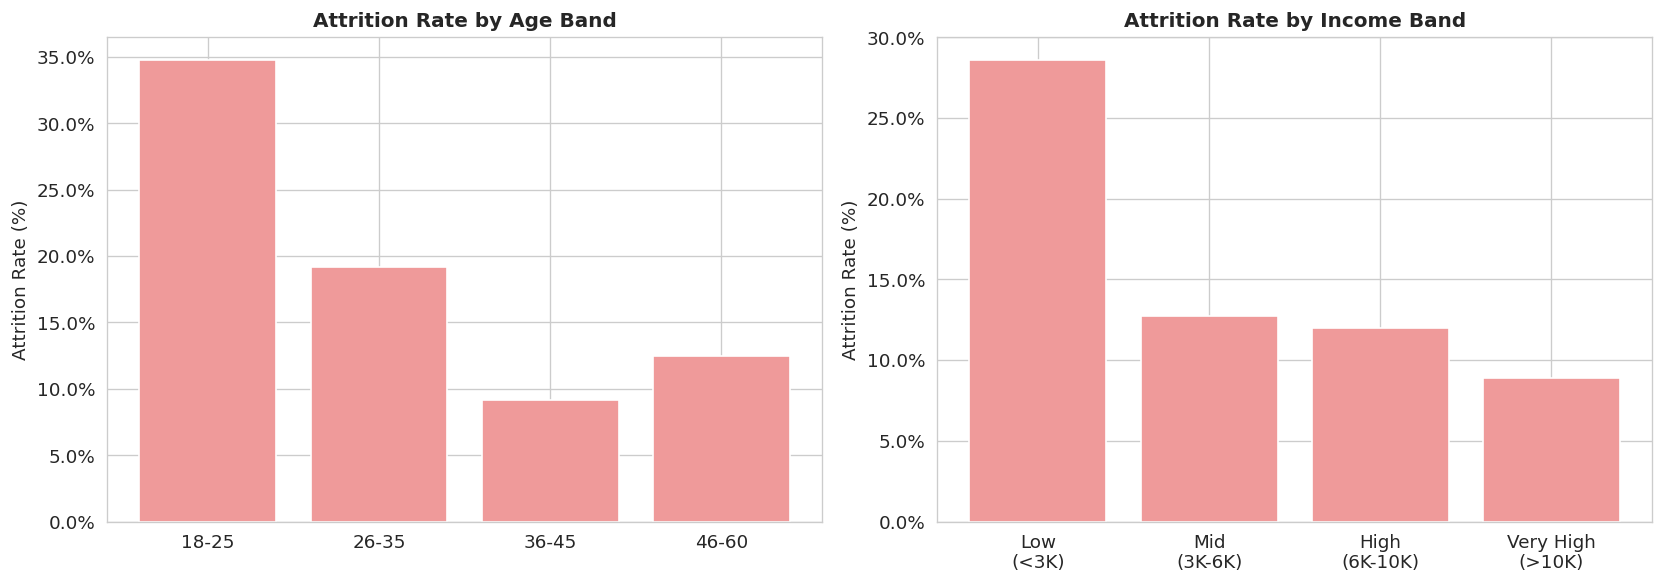

In [21]:
# 4.6  Age Bands & Income Groups
df_eda = df.copy()
df_eda['AgeBand']     = pd.cut(df_eda['Age'],
                                bins=[18, 25, 35, 45, 60],
                                labels=['18-25', '26-35', '36-45', '46-60'])
df_eda['IncomeBand']  = pd.cut(df_eda['MonthlyIncome'],
                                bins=[0, 3000, 6000, 10000, 20000],
                                labels=['Low\n(<3K)', 'Mid\n(3K-6K)',
                                        'High\n(6K-10K)', 'Very High\n(>10K)'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat, title in zip(axes,
                            ['AgeBand', 'IncomeBand'],
                            ['Age Band', 'Income Band']):
    temp = (df_eda.groupby(feat)['Attrition']
                  .apply(lambda x: (x == 'Yes').mean() * 100)
                  .reset_index()
                  .rename(columns={'Attrition': 'Rate'}))
    ax.bar(temp[feat].astype(str), temp['Rate'],
           color='#EF9A9A', edgecolor='white')
    ax.set_title(f'Attrition Rate by {title}',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Attrition Rate (%)')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

# Step 5: Feature Engineering

Feature engineering means creating NEW features from existing ones, or transforming them so machine learning models can understand them better.

Key tasks:
- Encode categorical variables (convert words → numbers)
- Create meaningful derived features
- Scale numeric features so no single feature dominates

In [22]:
# ── 5.1  Make a working copy ──────────────────────────────────
df_ml = df.copy()

# ── 5.2  Encode Target Variable ───────────────────────────────
# ML models need numbers, not text
df_ml['Attrition'] = df_ml['Attrition'].map({'Yes': 1, 'No': 0})

# ── 5.3  Encode Binary Categorical Columns ────────────────────
df_ml['OverTime'] = df_ml['OverTime'].map({'Yes': 1, 'No': 0})
df_ml['Gender']   = df_ml['Gender'].map({'Male': 1, 'Female': 0})

# ── 5.4  One-Hot Encode Multi-Class Categorical Columns ───────
# One-Hot Encoding creates a separate 0/1 column per category value
# drop_first=True avoids the 'dummy variable trap'
multi_cat_cols = ['BusinessTravel', 'Department', 'EducationField',
                  'JobRole', 'MaritalStatus']

df_ml = pd.get_dummies(df_ml, columns=multi_cat_cols, drop_first=True)
print(f"✅ One-hot encoding done. New shape: {df_ml.shape}")

# ── 5.5  Create New Features ──────────────────────────────────
# These derived features often capture patterns better than raw values

# How long since the employee was promoted relative to time at company?
df_ml['PromotionGap'] = df_ml['YearsAtCompany'] - df_ml['YearsSinceLastPromotion']

# Tenure ratio: How much of total career has been at this company?
df_ml['TenureRatio'] = np.where(
    df_ml['TotalWorkingYears'] > 0,
    df_ml['YearsAtCompany'] / df_ml['TotalWorkingYears'],
    0
)

# Income per year of experience (pay progression)
df_ml['IncomePerYearExp'] = np.where(
    df_ml['TotalWorkingYears'] > 0,
    df_ml['MonthlyIncome'] / df_ml['TotalWorkingYears'],
    df_ml['MonthlyIncome']
)

print("✅ New features created: PromotionGap, TenureRatio, IncomePerYearExp")

# ── 5.6  Verify Final Dataset ─────────────────────────────────
print(f"\n📐 Final ML-ready shape: {df_ml.shape}")
print(f"Attrition distribution: {df_ml['Attrition'].value_counts().to_dict()}")

✅ One-hot encoding done. New shape: (1470, 45)
✅ New features created: PromotionGap, TenureRatio, IncomePerYearExp

📐 Final ML-ready shape: (1470, 48)
Attrition distribution: {0: 1233, 1: 237}


In [23]:
# ── 5.7  Train-Test Split & Scaling ───────────────────────────

X = df_ml.drop('Attrition', axis=1)
y = df_ml['Attrition']

# Store column names for later (feature importance)
feature_names = X.columns.tolist()

# Stratified split: ensures both train/test have same class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📊 Train set: {X_train.shape[0]} samples")
print(f"📊 Test  set: {X_test.shape[0]} samples")
print(f"   Train Attrition rate: {y_train.mean()*100:.1f}%")
print(f"   Test  Attrition rate: {y_test.mean()*100:.1f}%")

# ── 5.8  Handle Class Imbalance with SMOTE ────────────────────
# SMOTE = Synthetic Minority Oversampling TEchnique
# It creates synthetic 'Yes' samples so the model doesn't just
# learn to always say 'No'
# IMPORTANT: Apply SMOTE only on TRAINING data, never on test data!

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\n⚖️  After SMOTE:")
print(f"   Train set size : {X_train_sm.shape[0]} samples")
print(f"   Class balance  : {dict(pd.Series(y_train_sm).value_counts())}")

# ── 5.9  Feature Scaling ──────────────────────────────────────
# Logistic Regression & SVM are sensitive to feature scale.
# StandardScaler makes every feature have mean=0, std=1.
# Fit on training data only → transform both train and test.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)

print("\n✅ Scaling complete. Ready for model training!")

📊 Train set: 1176 samples
📊 Test  set: 294 samples
   Train Attrition rate: 16.2%
   Test  Attrition rate: 16.0%

⚖️  After SMOTE:
   Train set size : 1972 samples
   Class balance  : {0: np.int64(986), 1: np.int64(986)}

✅ Scaling complete. Ready for model training!


# Step 6: Model Building

We train three different algorithms and compare them:

| Model | Type | Strengths |
|-------|------|-----------|
| **Logistic Regression** | Linear | Fast, interpretable, good baseline |
| **SVM (Support Vector Machine)** | Kernel-based | Works well with high-dimensional data |
| **Random Forest** | Ensemble | High accuracy, provides feature importance |

In [25]:
# 6.1  Define & Train All Three Models

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    'SVM'                : SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, max_depth=10,
                                                  random_state=42, n_jobs=-1)
}

results = {}
trained_models = {}

print("🚀 Training models...\n")

for name, model in models.items():
    print(f"  ⏳ Training: {name}")

    # Use scaled data for LR and SVM; unscaled for RF (tree-based, scale-invariant)
    if name == 'Random Forest':
        model.fit(X_train_sm, y_train_sm)
        y_pred      = model.predict(X_test)
        y_pred_prob = model.predict_proba(X_test)[:, 1]
    else:
        model.fit(X_train_scaled, y_train_sm)
        y_pred      = model.predict(X_test_scaled)
        y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        'Accuracy'  : accuracy_score(y_test, y_pred),
        'Precision' : precision_score(y_test, y_pred),
        'Recall'    : recall_score(y_test, y_pred),
        'F1-Score'  : f1_score(y_test, y_pred),
        'ROC-AUC'   : roc_auc_score(y_test, y_pred_prob),
        'y_pred'    : y_pred,
        'y_prob'    : y_pred_prob
    }
    trained_models[name] = model
    print(f"     ✅ {name} — Accuracy: {results[name]['Accuracy']*100:.2f}%  |  ROC-AUC: {results[name]['ROC-AUC']:.3f}")

print("\n✅ All models trained!")

🚀 Training models...

  ⏳ Training: Logistic Regression
     ✅ Logistic Regression — Accuracy: 85.71%  |  ROC-AUC: 0.819
  ⏳ Training: SVM
     ✅ SVM — Accuracy: 85.71%  |  ROC-AUC: 0.813
  ⏳ Training: Random Forest
     ✅ Random Forest — Accuracy: 82.65%  |  ROC-AUC: 0.758

✅ All models trained!


# Step 7: Model Comparison & Evaluation

In [26]:
# 7.1  Summary Table
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

summary = pd.DataFrame({
    name: {m: results[name][m] for m in metrics_cols}
    for name in results
}).T

print("\n📊 Model Performance Summary:")
print(summary.to_string(float_format='{:.4f}'.format))

# Highlight best in each column
summary.style\
    .highlight_max(axis=0, color='#C8E6C9')\
    .format('{:.4f}')


📊 Model Performance Summary:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.8571     0.5758  0.4043    0.4750   0.8193
SVM                    0.8571     0.6000  0.3191    0.4167   0.8126
Random Forest          0.8265     0.4375  0.2979    0.3544   0.7581


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.8571,0.5758,0.4043,0.4750,0.8193
SVM,0.8571,0.6000,0.3191,0.4167,0.8126
Random Forest,0.8265,0.4375,0.2979,0.3544,0.7581


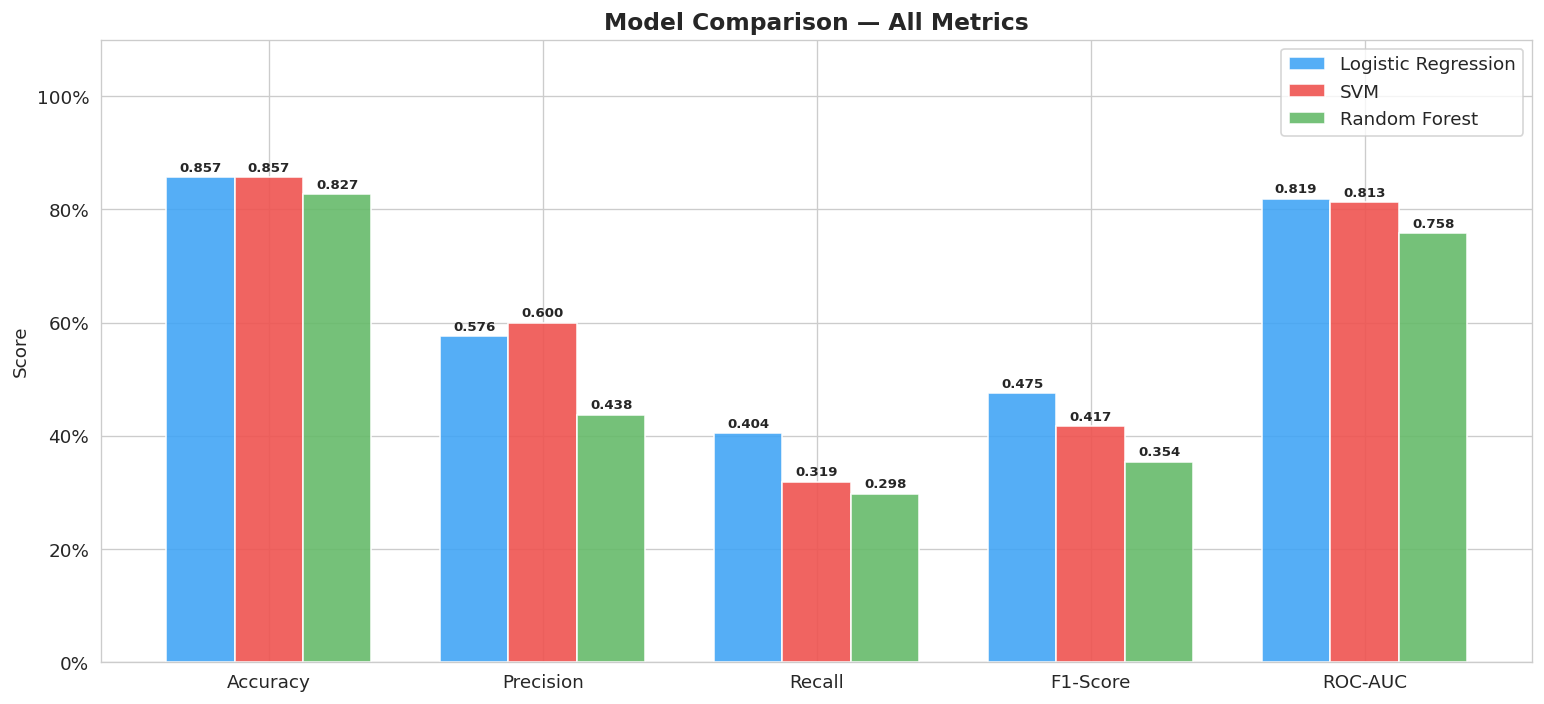

In [27]:
# 7.2  Comparative Bar Chart
fig, ax = plt.subplots(figsize=(13, 6))

x     = np.arange(len(metrics_cols))
width = 0.25
colors = ['#42A5F5', '#EF5350', '#66BB6A']

for i, (name, color) in enumerate(zip(results.keys(), colors)):
    vals = [results[name][m] for m in metrics_cols]
    bars = ax.bar(x + i * width, vals, width, label=name,
                  color=color, edgecolor='white', alpha=0.9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005, f'{v:.3f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_cols)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

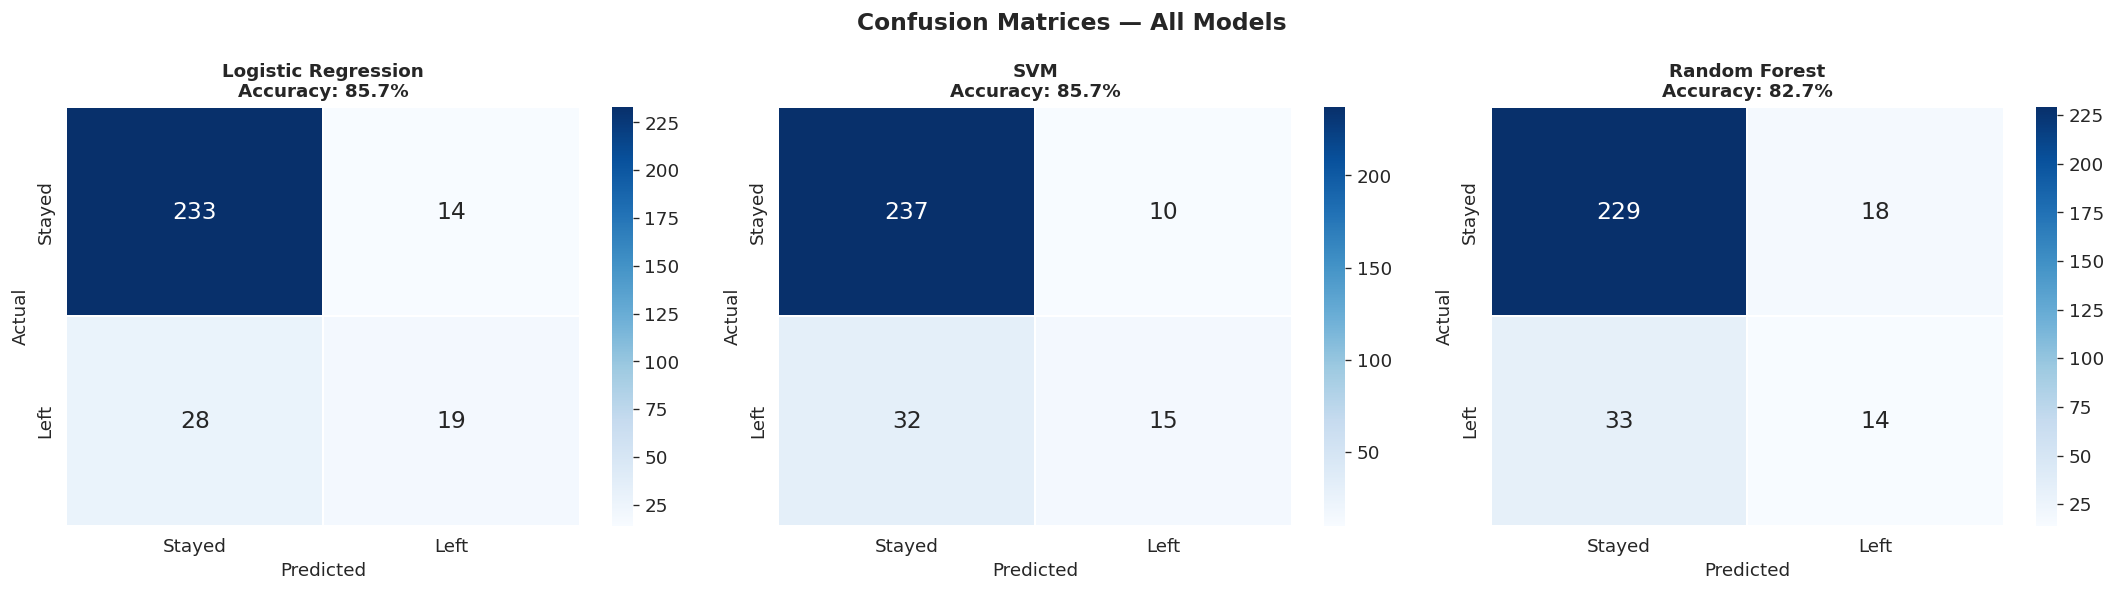

In [28]:
# 7.3  Confusion Matrices
# A confusion matrix shows how many predictions were right/wrong
#   True Positive (TP)  = Predicted Leave, Actually Left
#   False Negative (FN) = Predicted Stay, Actually Left  ← costly for HR!
#   True Negative (TN)  = Predicted Stay, Actually Stayed
#   False Positive (FP) = Predicted Leave, Actually Stayed

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name in zip(axes, results.keys()):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Stayed', 'Left'],
                yticklabels=['Stayed', 'Left'], ax=ax,
                linewidths=1, annot_kws={'size': 14})
    ax.set_title(f'{name}\nAccuracy: {results[name]["Accuracy"]*100:.1f}%',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

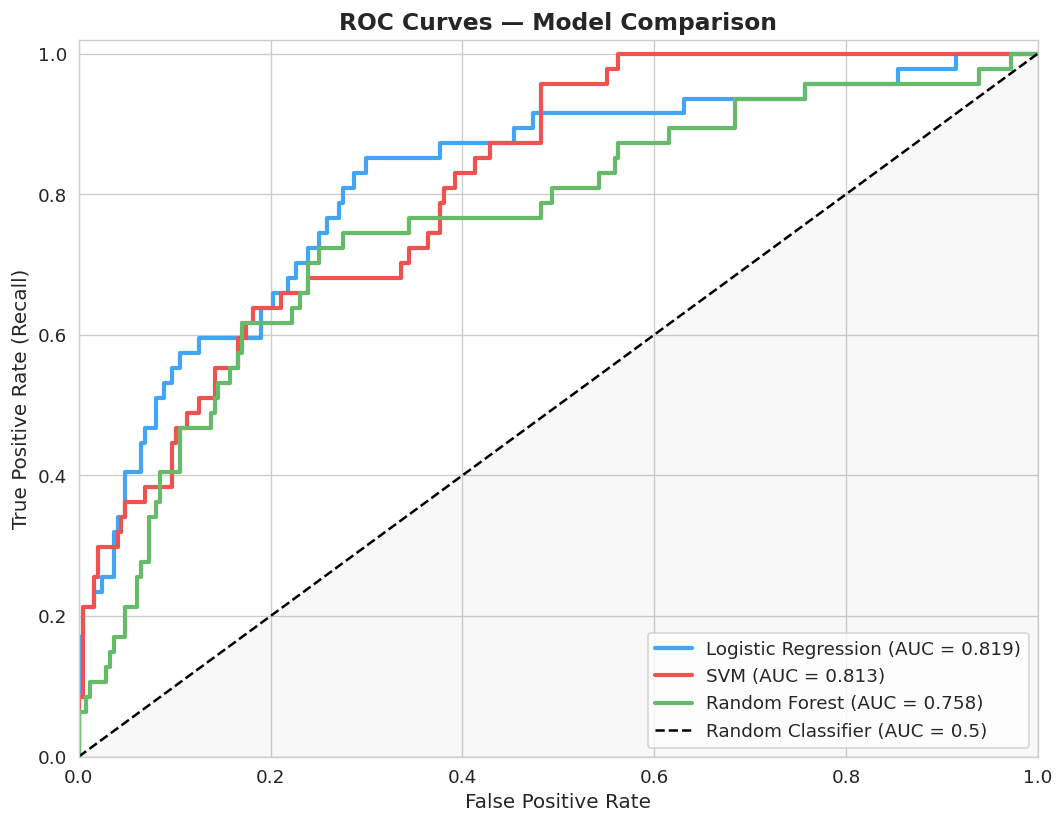

In [29]:
# 7.4  ROC Curves
# ROC-AUC: The closer to 1.0, the better the model distinguishes
#           between employees who stay vs leave

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#42A5F5', '#EF5350', '#66BB6A']

for name, color in zip(results.keys(), colors):
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    auc = results[name]['ROC-AUC']
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.5)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

In [30]:
# 7.5  Identify Best Model
best_model_name = max(results, key=lambda m: results[m]['F1-Score'])
best_model_obj  = trained_models[best_model_name]

print("=" * 55)
print(f"🏆 BEST MODEL: {best_model_name}")
print("=" * 55)
print(f"   Accuracy  : {results[best_model_name]['Accuracy']*100:.2f}%")
print(f"   Precision : {results[best_model_name]['Precision']:.4f}")
print(f"   Recall    : {results[best_model_name]['Recall']:.4f}")
print(f"   F1-Score  : {results[best_model_name]['F1-Score']:.4f}")
print(f"   ROC-AUC   : {results[best_model_name]['ROC-AUC']:.4f}")
print("=" * 55)
print("\n📋 Detailed Classification Report:")
print(classification_report(y_test, results[best_model_name]['y_pred'],
                             target_names=['Stayed', 'Left']))

🏆 BEST MODEL: Logistic Regression
   Accuracy  : 85.71%
   Precision : 0.5758
   Recall    : 0.4043
   F1-Score  : 0.4750
   ROC-AUC   : 0.8193

📋 Detailed Classification Report:
              precision    recall  f1-score   support

      Stayed       0.89      0.94      0.92       247
        Left       0.58      0.40      0.47        47

    accuracy                           0.86       294
   macro avg       0.73      0.67      0.70       294
weighted avg       0.84      0.86      0.85       294



In [31]:
# 7.6  Cross-Validation (Robustness Check)
# Cross-validation tells us if the model performs consistently
# across different data splits — not just lucky on one split

print("🔄 5-Fold Stratified Cross-Validation (using F1 Score):\n")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    if name == 'Random Forest':
        scores = cross_val_score(model, X, y, cv=skf, scoring='f1', n_jobs=-1)
    else:
        # For scaled models, use Pipeline in production; simplified here
        scores = cross_val_score(model, X, y, cv=skf, scoring='f1', n_jobs=-1)

    print(f"  {name:<25} F1 = {scores.mean():.4f}  (±{scores.std():.4f})")

🔄 5-Fold Stratified Cross-Validation (using F1 Score):

  Logistic Regression       F1 = 0.3036  (±0.0189)
  SVM                       F1 = 0.0000  (±0.0000)
  Random Forest             F1 = 0.2235  (±0.0393)


# Step 8: Key Insights & HR Action Plan

This is the most important section for the **HR team**. We translate model results into actionable business insights.

🔑 Top 20 Features Driving Attrition (Random Forest):
                         Feature  Importance
            MaritalStatus_Single    0.070938
                StockOptionLevel    0.054741
                 JobSatisfaction    0.045708
                   MonthlyIncome    0.043652
         EnvironmentSatisfaction    0.039981
                  JobInvolvement    0.039497
BusinessTravel_Travel_Frequently    0.037904
   JobRole_Laboratory Technician    0.034104
                        JobLevel    0.032668
                Department_Sales    0.031979
                    PromotionGap    0.030815
               TotalWorkingYears    0.030422
                             Age    0.030169
                     MonthlyRate    0.028648
                IncomePerYearExp    0.028220
            YearsWithCurrManager    0.028054
                      HourlyRate    0.026584
                 WorkLifeBalance    0.024919
                       DailyRate    0.023949
                  YearsAtCompany    0.023538


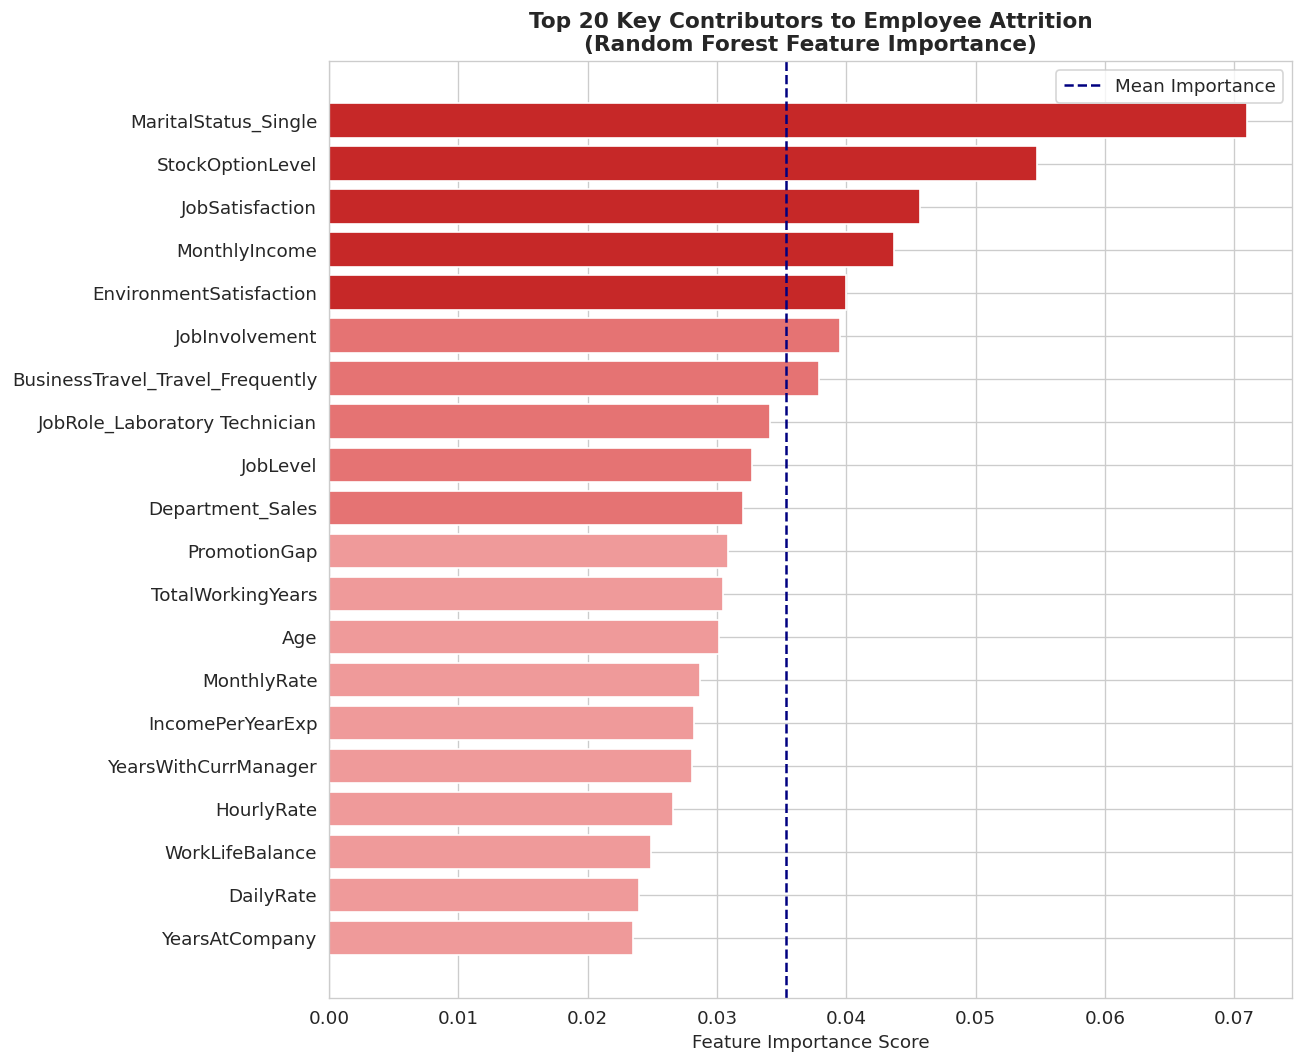

In [32]:
# 8.1  Random Forest Feature Importance
# Random Forest tells us which features it relied on most for predictions

rf_model = trained_models['Random Forest']
importances = rf_model.feature_importances_

feat_imp_df = (
    pd.DataFrame({'Feature': feature_names, 'Importance': importances})
      .sort_values('Importance', ascending=False)
      .head(20)
      .reset_index(drop=True)
)

print("🔑 Top 20 Features Driving Attrition (Random Forest):")
print(feat_imp_df.to_string(index=False))

# Visualise
plt.figure(figsize=(11, 9))
colors_bar = ['#C62828' if i < 5 else '#E57373' if i < 10 else '#EF9A9A'
              for i in range(20)]
plt.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1],
         color=colors_bar[::-1], edgecolor='white')
plt.xlabel('Feature Importance Score')
plt.title('Top 20 Key Contributors to Employee Attrition\n(Random Forest Feature Importance)',
          fontsize=13, fontweight='bold')
plt.axvline(x=feat_imp_df['Importance'].mean(), color='navy',
            linestyle='--', linewidth=1.5, label='Mean Importance')
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
# ── 8.2  HR Insight Summary Dashboard ────────────────────────
print("="*65)
print("       🏢 HR ATTRITION INSIGHTS — ACTION REPORT")
print("="*65)

# -- Insight 1: OverTime
ot_rate = df[df['OverTime']=='Yes']['Attrition'].eq('Yes').mean()*100
no_ot_rate = df[df['OverTime']=='No']['Attrition'].eq('Yes').mean()*100
print(f"""
🔴 INSIGHT 1 — OverTime is the #1 Flight Risk Factor
   Employees working OverTime leave at {ot_rate:.1f}% rate
   vs {no_ot_rate:.1f}% for those who don't.
   ➡️  ACTION: Audit teams with chronic overtime. Hire more staff,
              redistribute workload, or offer comp-time policies.
""")

# -- Insight 2: Young employees
young_rate = df[df['Age']<=30]['Attrition'].eq('Yes').mean()*100
print(f"""🔴 INSIGHT 2 — Young Employees (18–30) Are Leaving Fast
   Attrition rate for under-30s: {young_rate:.1f}%
   ➡️  ACTION: Introduce early-career development programs, mentorship,
              and clear promotion timelines for junior staff.
""")

# -- Insight 3: Monthly income
left_income   = df[df['Attrition']=='Yes']['MonthlyIncome'].median()
stayed_income = df[df['Attrition']=='No']['MonthlyIncome'].median()
print(f"""🔴 INSIGHT 3 — Below-Market Compensation Drives Exits
   Median income of those who LEFT : ${left_income:,.0f}/month
   Median income of those who STAYED: ${stayed_income:,.0f}/month
   ➡️  ACTION: Conduct a market pay benchmarking study. Prioritise
              salary adjustments for Sales Reps and Lab Technicians.
""")

# -- Insight 4: Distance from home
far_rate  = df[df['DistanceFromHome']>15]['Attrition'].eq('Yes').mean()*100
near_rate = df[df['DistanceFromHome']<=5]['Attrition'].eq('Yes').mean()*100
print(f"""🟡 INSIGHT 4 — Long Commute Increases Attrition
   Attrition for distance >15 km : {far_rate:.1f}%
   Attrition for distance <=5 km : {near_rate:.1f}%
   ➡️  ACTION: Introduce hybrid/remote work options for employees
              living far from the office.
""")

# -- Insight 5: Years since promotion
stale_rate = df[df['YearsSinceLastPromotion']>=4]['Attrition'].eq('Yes').mean()*100
recent_rate = df[df['YearsSinceLastPromotion']<=1]['Attrition'].eq('Yes').mean()*100
print(f"""🟡 INSIGHT 5 — Stagnant Careers Accelerate Departures
   Attrition where no promo in 4+ yrs : {stale_rate:.1f}%
   Attrition with recent promo (<1 yr) : {recent_rate:.1f}%
   ➡️  ACTION: Set up regular career-path check-ins. Implement a
              clear 2-year promotion review cycle.
""")

# -- Insight 6: Job Role
role_attrition = (df.groupby('JobRole')['Attrition']
                    .apply(lambda x: (x=='Yes').mean()*100)
                    .sort_values(ascending=False)
                    .head(3))
print(f"""🟡 INSIGHT 6 — High-Risk Job Roles
   Top 3 roles with highest attrition:""")
for role, rate in role_attrition.items():
    print(f"     • {role:<35} → {rate:.1f}%")
print("   ➡️  ACTION: Run targeted retention interviews with employees\n"
      "              in these roles. Check manager quality & workload.")

# -- Insight 7: Satisfaction
low_env_rate = df[df['EnvironmentSatisfaction']==1]['Attrition'].eq('Yes').mean()*100
print(f"""
🟢 INSIGHT 7 — Low Satisfaction is a Clear Warning Signal
   Attrition for EnvironmentSatisfaction=1 (Lowest): {low_env_rate:.1f}%
   ➡️  ACTION: Run quarterly pulse surveys. Flag employees with 2+
              consecutive low scores for manager follow-up.
""")

print("="*65)
print("⚡ Overall Attrition Rate:", f"{df['Attrition'].eq('Yes').mean()*100:.1f}%")
print("   Industry benchmark is typically 10–15%.")
print("="*65)

       🏢 HR ATTRITION INSIGHTS — ACTION REPORT

🔴 INSIGHT 1 — OverTime is the #1 Flight Risk Factor
   Employees working OverTime leave at 30.5% rate
   vs 10.4% for those who don't.
   ➡️  ACTION: Audit teams with chronic overtime. Hire more staff,
              redistribute workload, or offer comp-time policies.

🔴 INSIGHT 2 — Young Employees (18–30) Are Leaving Fast
   Attrition rate for under-30s: 25.9%
   ➡️  ACTION: Introduce early-career development programs, mentorship,
              and clear promotion timelines for junior staff.

🔴 INSIGHT 3 — Below-Market Compensation Drives Exits
   Median income of those who LEFT : $3,202/month
   Median income of those who STAYED: $5,204/month
   ➡️  ACTION: Conduct a market pay benchmarking study. Prioritise
              salary adjustments for Sales Reps and Lab Technicians.

🟡 INSIGHT 4 — Long Commute Increases Attrition
   Attrition for distance >15 km : 20.7%
   Attrition for distance <=5 km : 13.8%
   ➡️  ACTION: Introduce hybrid/re

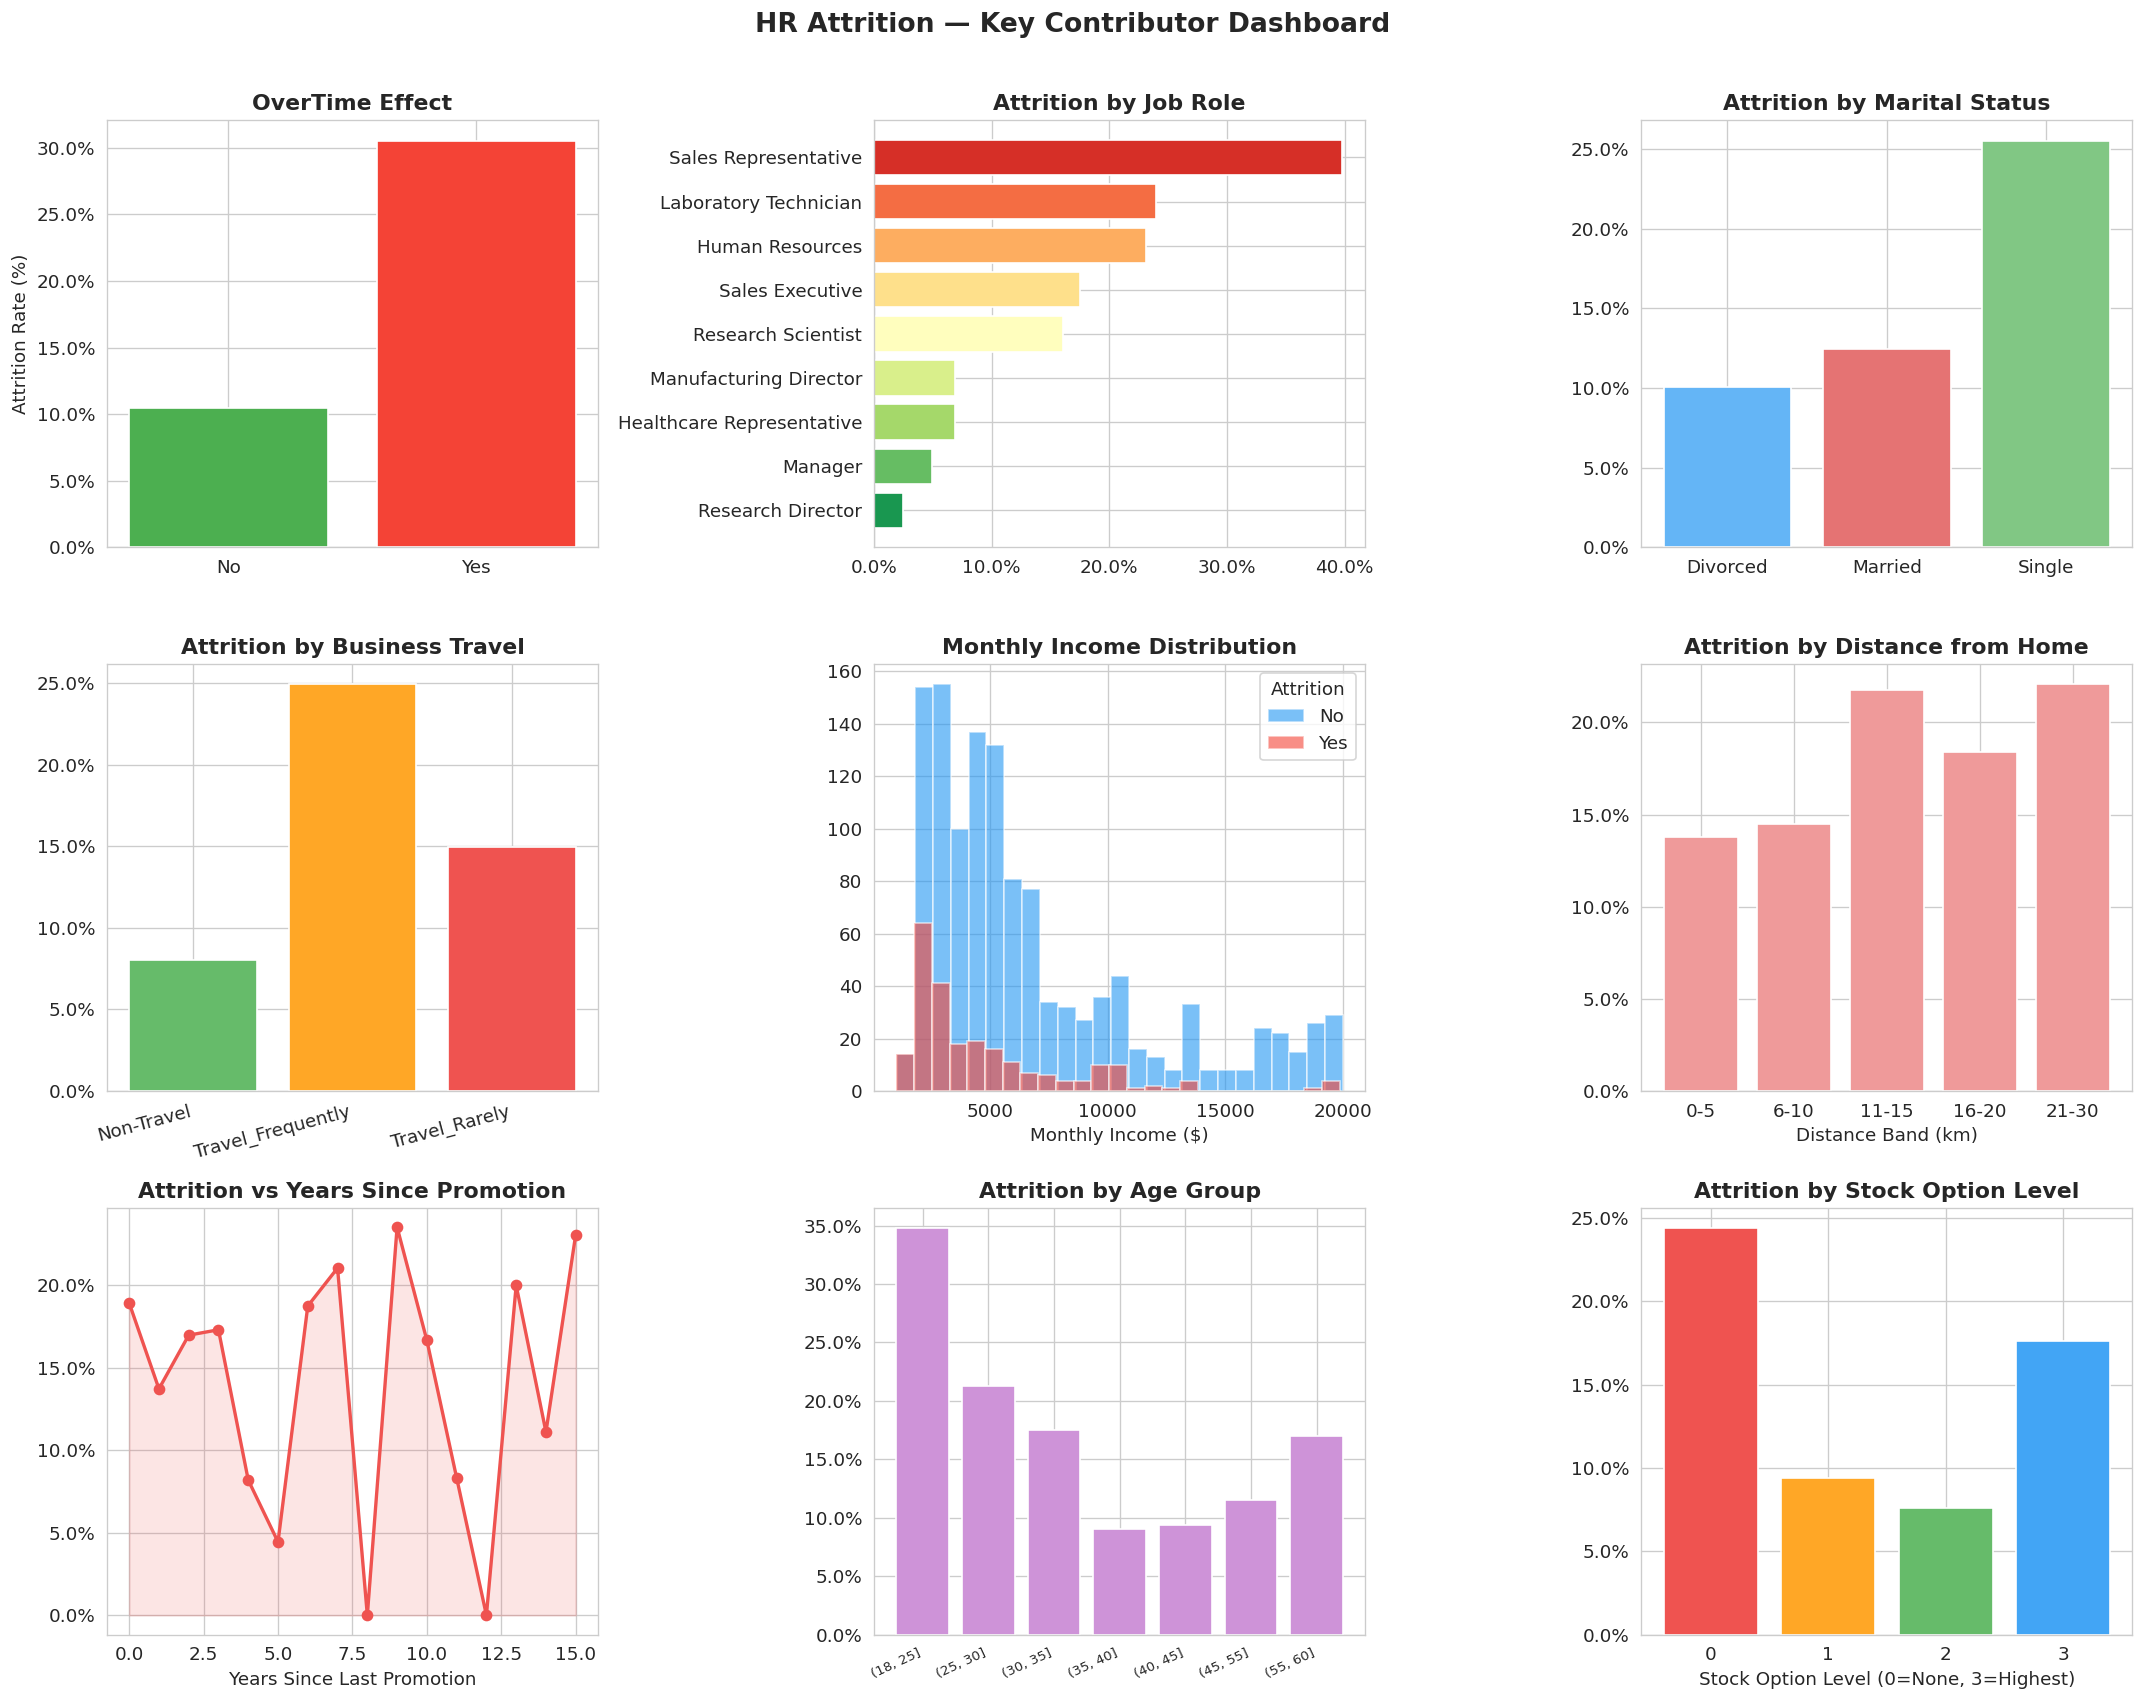


✅ Dashboard saved as 'HR_Attrition_Dashboard.png'


In [34]:
# ── 8.3  Visual HR Action Dashboard ──────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle('HR Attrition — Key Contributor Dashboard',
             fontsize=16, fontweight='bold', y=1.01)

# 1. OverTime
ax1 = fig.add_subplot(3, 3, 1)
ot_data = df.groupby('OverTime')['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
ax1.bar(ot_data.index, ot_data.values, color=['#4CAF50', '#F44336'], edgecolor='white')
ax1.set_title('OverTime Effect', fontweight='bold')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.set_ylabel('Attrition Rate (%)')

# 2. Job Role
ax2 = fig.add_subplot(3, 3, 2)
role_data = (df.groupby('JobRole')['Attrition']
               .apply(lambda x: (x=='Yes').mean()*100)
               .sort_values(ascending=True))
ax2.barh(role_data.index, role_data.values,
         color=sns.color_palette('RdYlGn_r', len(role_data)))
ax2.set_title('Attrition by Job Role', fontweight='bold')
ax2.xaxis.set_major_formatter(mtick.PercentFormatter())

# 3. MaritalStatus
ax3 = fig.add_subplot(3, 3, 3)
ms_data = df.groupby('MaritalStatus')['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
ax3.bar(ms_data.index, ms_data.values,
        color=['#64B5F6', '#E57373', '#81C784'], edgecolor='white')
ax3.set_title('Attrition by Marital Status', fontweight='bold')
ax3.yaxis.set_major_formatter(mtick.PercentFormatter())

# 4. Business Travel
ax4 = fig.add_subplot(3, 3, 4)
bt_data = df.groupby('BusinessTravel')['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
ax4.bar(bt_data.index, bt_data.values,
        color=['#66BB6A', '#FFA726', '#EF5350'], edgecolor='white')
ax4.set_title('Attrition by Business Travel', fontweight='bold')
ax4.set_xticklabels(bt_data.index, rotation=15, ha='right')
ax4.yaxis.set_major_formatter(mtick.PercentFormatter())

# 5. Income Distribution
ax5 = fig.add_subplot(3, 3, 5)
for label, color in ATTRITION_COLORS.items():
    ax5.hist(df[df['Attrition']==label]['MonthlyIncome'],
             bins=25, alpha=0.6, color=color, label=label)
ax5.set_title('Monthly Income Distribution', fontweight='bold')
ax5.set_xlabel('Monthly Income ($)')
ax5.legend(title='Attrition')

# 6. Distance from Home
ax6 = fig.add_subplot(3, 3, 6)
bins = [0, 5, 10, 15, 20, 30]
labels = ['0-5', '6-10', '11-15', '16-20', '21-30']
df_temp = df.copy()
df_temp['DistBand'] = pd.cut(df_temp['DistanceFromHome'], bins=bins, labels=labels)
dist_data = df_temp.groupby('DistBand')['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
ax6.bar(dist_data.index.astype(str), dist_data.values,
        color='#EF9A9A', edgecolor='white')
ax6.set_title('Attrition by Distance from Home', fontweight='bold')
ax6.set_xlabel('Distance Band (km)')
ax6.yaxis.set_major_formatter(mtick.PercentFormatter())

# 7. Years Since Promotion
ax7 = fig.add_subplot(3, 3, 7)
promo_data = df.groupby('YearsSinceLastPromotion')['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
ax7.plot(promo_data.index, promo_data.values, 'o-', color='#EF5350', lw=2)
ax7.fill_between(promo_data.index, promo_data.values, alpha=0.15, color='#EF5350')
ax7.set_title('Attrition vs Years Since Promotion', fontweight='bold')
ax7.set_xlabel('Years Since Last Promotion')
ax7.yaxis.set_major_formatter(mtick.PercentFormatter())

# 8. Age vs Attrition
ax8 = fig.add_subplot(3, 3, 8)
age_data = (df.groupby(pd.cut(df['Age'], bins=[18,25,30,35,40,45,55,60]))
              ['Attrition'].apply(lambda x: (x=='Yes').mean()*100))
ax8.bar([str(i) for i in age_data.index], age_data.values,
        color='#CE93D8', edgecolor='white')
ax8.set_title('Attrition by Age Group', fontweight='bold')
ax8.set_xticklabels([str(i) for i in age_data.index], rotation=25, ha='right', fontsize=8)
ax8.yaxis.set_major_formatter(mtick.PercentFormatter())

# 9. Stock Option Level
ax9 = fig.add_subplot(3, 3, 9)
stock_data = df.groupby('StockOptionLevel')['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
ax9.bar(stock_data.index.astype(str), stock_data.values,
        color=['#EF5350', '#FFA726', '#66BB6A', '#42A5F5'], edgecolor='white')
ax9.set_title('Attrition by Stock Option Level', fontweight='bold')
ax9.set_xlabel('Stock Option Level (0=None, 3=Highest)')
ax9.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.savefig('HR_Attrition_Dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Dashboard saved as 'HR_Attrition_Dashboard.png'")

In [ ]:
import joblib

# Create a dictionary or list to keep them together
production_artifacts = {
    'model': trained_models['Logistic Regression'],
    'scaler': scaler,
    'features': feature_names
}

# Save to a file
joblib.dump(production_artifacts, 'logistic_regression_model.pkl')
print("✅ Model and Scaler saved successfully!")